# Uncertainty Quantification for LLMs: A Comprehensive Tutorial

Welcome to this interactive tutorial on estimating uncertainty in Large Language Models (LLMs) applied to the clinical domain.

This notebook provides a hands-on approach to Uncertainty Quantification (UQ) by leveraging two state-of-the-art Python libraries: **`lm-polygraph`** and **`uqlm`**.

##### Load  the requested libraries

In [1]:
## CELL 0: ENVIRONMENT SETUP (Run this first!)
!pip install -q lm-polygraph uqlm transformers accelerate langchain langchain-huggingface langchain_openai langchain-google-genai langchain-anthropic langchain_ollama

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.7/137.7 kB 15.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.9/267.9 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
# ==========================================
# 1. SYSTEM CONFIGURATION (Strictly before importing Torch!)
# ==========================================
import os
# Prevents VRAM fragmentation on Colab (Must precede import torch)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ==========================================
# 2. STANDARD PYTHON LIBRARIES
# ==========================================
import gc
import json
import types
import random
import asyncio
import getpass
import inspect
import subprocess
import time
from typing import Optional, Union, Any, Dict, List
import requests
import pandas as pd
import io
import base64

# ==========================================
# 3. DATA SCIENCE & DEEP LEARNING LIBRARIES
# ==========================================
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline


##### Fix a random seed to ensure reproducibility of your experiment

In [2]:
import numpy as np

# --- Setting seed for Scientific Reproducibility ---
RANDOM_SEED = 42

def set_global_seed(seed=RANDOM_SEED):
    """Locks the random seed for predictable, reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed()


The `prepare_dataset` function loads a QA Dataset from Hugging Face, standardizes its schema by merging textual context with the question, and splits the sampled records into isolated training and testing sets.

In [ ]:
import os
from datasets import load_dataset
from sklearn.model_selection import train_test_split


def prepare_dataset(
    path: str = "pubmed_qa",
    name: Optional[str] = None,
    split: str = "train",
    max_samples: int = 30,
    test_size: float = 0.33,
    random_state: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Loads clinical benchmark datasets (both text-only and multimodal) from Hugging Face Hub,
    standardizes their schema, extracts image data into base64 if present,
    and outputs isolated, leakage-free Train/Test splits.
    """
    print(f"⏳ Loading clinical dataset directly from Hugging Face Hub ({path})...")

    # 1. Caricamento dello split richiesto
    raw_dataset = load_dataset(path, name, split=split)
    raw_df = raw_dataset.to_pandas()

    # 2. Campionamento controllato
    if max_samples and max_samples < len(raw_df):
        raw_df = raw_df.sample(frac=1, random_state=random_state).reset_index(drop=True).head(max_samples)
    else:
        raw_df = raw_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    standardized_records = []
    image_col = next((col for col in ["image", "img"] if col in raw_df.columns), None)
    has_images = image_col is not None

    # 3. Pipeline di standardizzazione e codifica
    for idx, row in raw_df.iterrows():
        question_text = ""
        answer_text = ""

        if path == "pubmed_qa" or name == "pqa_labeled":
            contexts = row["context"]
            context_str = " ".join(contexts["contexts"]) if isinstance(contexts, dict) and "contexts" in contexts else ""
            question_text = f"Context: {context_str}\nQuestion: {row['question']}"
            answer_text = row["final_decision"]
        else:
            for q_key in ["question", "phrase", "text", "query"]:
                if q_key in row and pd.notna(row[q_key]):
                    question_text = row[q_key]
                    break
            for a_key in ["answer", "final_decision", "label", "target"]:
                if a_key in row and pd.notna(row[a_key]):
                    answer_text = row[a_key]
                    break

        # Codifica dell'immagine in stringa Base64 standard
        encoded_image = None
        mime_type = None
        if has_images and row[image_col] is not None:
            try:
                img_data = row[image_col]
                if isinstance(img_data, dict) and "bytes" in img_data and img_data["bytes"] is not None:
                    img = Image.open(io.BytesIO(img_data["bytes"]))
                elif hasattr(img_data, "convert"):
                    img = img_data
                else:
                    continue

                buffered = io.BytesIO()
                img.convert("RGB").save(buffered, format="PNG")
                encoded_image = base64.b64encode(buffered.getvalue()).decode("utf-8")
                mime_type = "image/png"
            except Exception as e:
                print(f"⚠️ Errore di codifica per l'asset visivo all'indice {idx}: {e}")
                continue

        if question_text or answer_text:
            standardized_records.append({
                "question": question_text,
                "answer": str(answer_text).strip(),
                "image_base64": encoded_image,
                "image_mime": mime_type
            })

    standardized_df = pd.DataFrame(standardized_records)

    # 4. Splittaggio Train/Test
    train_df, test_df = train_test_split(
        standardized_df,
        test_size=test_size,
        random_state=random_state
    )

    print(f"📊 Dataset processing complete via native Hybrid Engine!")
    print(f"   └── Operational Mode: {'MULTIMODAL (Vision-Language)' if has_images else 'TEXT-ONLY'}")
    print(f"   └── 📈 Train size (Calibration Fitting Pool): {len(train_df)} samples")
    print(f"   └── 📉 Test size (Holdout Evaluation Pool):  {len(test_df)} samples\n")

    return train_df, test_df


## **`UQEngineContext` Utility**

The `UQEngineContext` class manages the lifecycle of your models. It allows you to orchestrate multiple models under custom nicknames (**aliases**), configure their operational modes independently, inspect live allocations, and purge them to free up memory.

> 💡 **Core Architectural Rule:** Operational modes (`"white"` vs `"black"`) are **strictly model-specific**, not library-specific. Every single model you load is completely isolated. You can run a White-Box model and a Black-Box model simultaneously within the same context manager.

---

### **1. Initialize the Context (Set Fallback Defaults)**

Create the master manager instance. The parameters passed here act *only* as fallback defaults if you omit the `mode` parameter during individual loading calls.

```python
# Sets the default behavior rules for the session
engine = UQEngineContext(default_polygraph_mode="white", default_uqlm_mode="black")

```

---

### **2. Load a Polygraph Model (`.load_polygraph`)**

Use this method to initialize backbones for the **LM-Polygraph** framework.

* **Basic Usage:**

```python
# Configures THIS specific model instance in White-Box mode
engine.load_polygraph(model_id="google/gemma-2-2b-it", alias="gemma_local", mode="white", quant_mode="4bit")

```

* **Key Arguments:**
* `model_id`: The Hugging Face repository directory path.
* `alias`: Your custom tracking nickname (e.g., `"gemma_local"`). This completely isolates the instance.
* `mode`: **Model-Specific Override.** Explicitly force `"white"` (local logprobs) or `"black"` (API) for this alias.
* `quant_mode`: Set to `"4bit"` or `"8bit"` to compress local models and preserve hardware VRAM.



---

### **3. Load a UQLM Model (`.load_uqlm`)**

Use this method to initialize backbones through LangChain for the **UQLM** calibration framework.

* **Basic Usage:**

```python
# Configures THIS specific model instance in Black-Box mode via API
engine.load_uqlm(provider="openai", model_id="gpt-4o", alias="gpt_api", mode="black", temperature=0.0)

```

* **Key Arguments:**
* `provider`: Supported backends: `"openai"`, `"google"`, `"anthropic"`, `"ollama"`, or `"custom"`.
* `model_id`: The specific engine identifier tag or API model name.
* `mode`: **Model-Specific Override.** Choose how this specific alias isolates token parameters, independent of other environments.
* **Ollama Automation:** If you select `"ollama"` and the weights are missing locally, the function automatically initializes a real-time download progress stream.



---

### **4. Inspect Live Deployments (`.get_active_models`)**

Before wiping resources, you can query the environment memory map to view precisely which models are currently consuming system resources.

* **Basic Usage:**

```python
engine.get_active_models()

```

* **Sample Console Output Summary:**
```text
=======================================================
📋 LIVE UNCERTAINTY QUANTIFICATION REGISTRIES
=======================================================
🔹 lm_polygraph Framework (1 active):
  • Alias: [GEMMA_LOCAL] ➔ Operational Mode: WHITE-BOX

🔸 UQLM Calibration Framework (1 active):
  • Alias: [GPT_API] ➔ Operational Mode: BLACK-BOX
=======================================================

```



---

### **5. Flush Memory & Prevent Crashes (`.unload`)**

Your definitive safety net against fatal Out-Of-Memory (OOM) errors. Call this whenever you finish a workflow stage to wipe the GPU memory completely clean before loading your next configuration.

* **Purge Everything:**

```python
engine.unload()  # Deletes all active model aliases and flushes CUDA VRAM cache

```

* **Purge a Specific Model Instance:**

```python
engine.unload(aliases="gemma_local")  # Clears only the targeted model alias

```

* **Purge a List of Models:**

```python
engine.unload(aliases=["gemma_local", "gpt_api"])

```





In [3]:
# --- lm_polygraph Imports ---
from transformers import AutoProcessor, AutoModelForImageTextToText, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from lm_polygraph.utils.model import BlackboxModel, WhiteboxModel
from lm_polygraph.model_adapters import VisualWhiteboxModel
from lm_polygraph.utils.generation_parameters import GenerationParameters

# --- LangChain Imports ---
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama

class UQEngineContext:
    """
    Manager class for Uncertainty Quantification Models.
    Handles multi-model setups with independent operational modes (white/black box) per alias.
    """
    def __init__(self, default_polygraph_mode: str = "black", default_uqlm_mode: str = "black"):
        self.default_polygraph_mode = default_polygraph_mode.strip().lower()
        self.default_uqlm_mode = default_uqlm_mode.strip().lower()

        self.polygraph_models: dict[str, Any] = {}
        self.langchain_llms: dict[str, Any] = {}

        self.polygraph_modes: dict[str, str] = {}
        self.uqlm_modes: dict[str, str] = {}

    # ==========================================
    # DIAGNOSTIC REGISTER MANAGEMENT
    # ==========================================
    def get_active_models(self) -> None:
        """
        Prints a structural summary of all currently live model aliases
        and their assigned operational boundaries.
        """
        print("\n" + "="*55)
        print("📋 LIVE UNCERTAINTY QUANTIFICATION REGISTRIES")
        print("="*55)

        poly_aliases = list(self.polygraph_models.keys())
        uqlm_aliases = list(self.langchain_llms.keys())

        print(f"🔹 lm_polygraph Framework ({len(poly_aliases)} active):")
        if not poly_aliases:
            print("  (No active aliases allocated)")
        for alias in poly_aliases:
            mode = self.polygraph_modes.get(alias, "unknown").upper()
            print(f"  • Alias: [{alias.upper()}] ➔ Operational Mode: {mode}-BOX")

        print(f"\n🔸 UQLM Calibration Framework ({len(uqlm_aliases)} active):")
        if not uqlm_aliases:
            print("  (No active aliases allocated)")
        for alias in uqlm_aliases:
            mode = self.uqlm_modes.get(alias, "unknown").upper()
            print(f"  • Alias: [{alias.upper()}] ➔ Operational Mode: {mode}-BOX")
        print("="*55 + "\n")

    # ==========================================
    # POLYGRAPH MANAGEMENT (Independent Modes)
    # ==========================================
    def load_polygraph(self,
                       model_id: str,
                       alias: str = "default",
                       mode: Optional[str] = None,
                       is_multimodal: bool = False,
                       quant_mode: str = "none",
                       temperature: float = 0.7,
                       max_new_tokens: int = 30,
                       do_sample: bool = True,
                       device_map: str = "auto",
                       attn_implementation: str = "eager",
                       **hf_extra_kwargs):
        """Loads an lm_polygraph model natively with an independent box mode."""
        current_mode = mode.strip().lower() if mode else self.default_polygraph_mode
        if current_mode == "none":
            print(f"⚠️ Polygraph mode is set to 'none'. Skipping load for alias '{alias}'.")
            return

        print(f"\n⚙️ Setting up lm_polygraph [{alias.upper()}] in {current_mode.upper()}-BOX mode...")
        self.polygraph_modes[alias] = current_mode

        shared_generation_params = GenerationParameters(
            temperature=temperature, do_sample=do_sample, max_new_tokens=max_new_tokens
        )

        if current_mode == "white":
            if "HF_TOKEN" not in os.environ:
                os.environ["HF_TOKEN"] = getpass.getpass("Paste your Hugging Face Token: ")

            model_loader_class = hf_extra_kwargs.pop("model_loader_class", AutoModelForImageTextToText)
            model_kwargs = {"device_map": device_map if torch.cuda.is_available() else "cpu", "token": os.environ["HF_TOKEN"]}

            if attn_implementation:
                model_kwargs["attn_implementation"] = attn_implementation

            if "trust_remote_code" not in hf_extra_kwargs:
                model_kwargs["trust_remote_code"] = True

            model_kwargs.update(hf_extra_kwargs)

            if quant_mode == '4bit':
                model_kwargs["quantization_config"] = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
            elif quant_mode == '8bit':
                model_kwargs["quantization_config"] = BitsAndBytesConfig(load_in_8bit=True)
            else:
                model_kwargs["torch_dtype"] = torch.float16

            if is_multimodal:
                processor = AutoProcessor.from_pretrained(
                    model_id,
                    token=os.environ["HF_TOKEN"],
                    trust_remote_code=model_kwargs.get("trust_remote_code", True)
                )
                base_model = model_loader_class.from_pretrained(model_id, **model_kwargs)
                self.polygraph_models[alias] = VisualWhiteboxModel(
                    model=base_model, processor_visual=processor, model_path=model_id, generation_parameters=shared_generation_params
                )
            else:
                tokenizer = AutoTokenizer.from_pretrained(model_id, token=os.environ["HF_TOKEN"])
                base_model = AutoModelForCausalLM.from_pretrained(model_id, **model_kwargs)
                self.polygraph_models[alias] = WhiteboxModel(
                    model=base_model, tokenizer=tokenizer, model_path=model_id, generation_parameters=shared_generation_params
                )
        else:
            if "OPENAI_API_KEY" not in os.environ:
                os.environ["OPENAI_API_KEY"] = getpass.getpass("Paste your OpenAI API Key: ")
            if "HF_TOKEN" not in os.environ:
                os.environ["HF_TOKEN"] = getpass.getpass("Paste your Hugging Face Token: ")

            self.polygraph_models[alias] = BlackboxModel(
                model_path=model_id, openai_api_key=os.environ.get("OPENAI_API_KEY"), hf_api_token=os.environ.get("HF_TOKEN"), supports_logprobs=True, generation_parameters=shared_generation_params
            )



    def load_uqlm(self,
                  provider: str,
                  model_id: Optional[str] = None,
                  alias: str = "default",
                  mode: Optional[str] = None,
                  temperature: float = 0.7,
                  max_tokens: Optional[int] = None,
                  custom_llm: Optional[Any] = None,
                  ollama_url: str = "http://localhost:11434",
                  auto_install: bool = False,
                  **uqlm_kwargs):
        """Loads a LangChain LLM with an independent box mode mapping."""
        current_mode = mode.strip().lower() if mode else self.default_uqlm_mode
        if current_mode == "none":
            return

        provider = provider.strip().lower()

        if current_mode == "white" and provider in ["anthropic", "google"]:
            print(f"⚠️ CRITICAL WARNING: Provider '{provider.upper()}' for alias '{alias}' does not support White-Box logprobs. Forcing Black-Box.")
            current_mode = "black"

        self.uqlm_modes[alias] = current_mode
        print(f"\n📊 Setting up UQLM [{alias.upper()}] in {current_mode.upper()}-BOX mode...")

        if provider == "custom":
            self.langchain_llms[alias] = custom_llm
            return

        if provider == "openai":
            if "OPENAI_API_KEY" not in os.environ:
                os.environ["OPENAI_API_KEY"] = getpass.getpass("Paste your OpenAI Key: ")
            openai_kwargs = {"logprobs": True} if current_mode == "white" else {}
            self.langchain_llms[alias] = ChatOpenAI(model=model_id, temperature=temperature, max_tokens=max_tokens, model_kwargs=openai_kwargs, **uqlm_kwargs)
        elif provider == "google":
            if "GOOGLE_API_KEY" not in os.environ:
                os.environ["GOOGLE_API_KEY"] = getpass.getpass("Paste your Google Key: ")
            self.langchain_llms[alias] = ChatGoogleGenerativeAI(model=model_id, temperature=temperature, max_tokens=max_tokens, **uqlm_kwargs)
        elif provider == "anthropic":
            if "ANTHROPIC_API_KEY" not in os.environ:
                os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Paste your Anthropic Key: ")
            self.langchain_llms[alias] = ChatAnthropic(model=model_id, temperature=temperature, max_tokens=max_tokens, **uqlm_kwargs)

        elif provider == "ollama":
            manager = OllamaManager(base_url=ollama_url)

            if not manager.load_model(model_name=model_id, auto_install=auto_install):
                print(f"❌ Aborting allocation for alias [{alias.upper()}]: Model download or service failed.")
                return

            if current_mode == "white":
                uqlm_kwargs.pop("base_url", None)
                self.langchain_llms[alias] = ChatOpenAI(
                    base_url=f"{ollama_url}/v1",
                    api_key="ollama",
                    model=model_id,
                    temperature=temperature,
                    max_tokens=max_tokens,
                    model_kwargs={"logprobs": True},
                    **uqlm_kwargs
                )
                print(f"🔗 Ollama White-Box instance generated via compatibility layer ({ollama_url}/v1)")
            else:
                uqlm_kwargs["base_url"] = ollama_url
                self.langchain_llms[alias] = ChatOllama(model=model_id, temperature=temperature, **uqlm_kwargs)

    def unload(self, aliases: Optional[Union[list[str], str]] = None) -> None:
        """
        Safely unloads specified model aliases or all models from memory,
        breaking references to force garbage collection and flush GPU VRAM cache.
        """
        if aliases is None:
            all_targets = list(set(list(self.polygraph_models.keys()) + list(self.langchain_llms.keys())))
        elif isinstance(aliases, str):
            all_targets = [aliases.strip()]
        else:
            all_targets = [a.strip() for a in aliases]

        if not all_targets:
            print("🧹 No active models found in registries to unload.")
            return

        print(f"\n🧹 Initiating memory purge for target aliases: {all_targets}")

        for alias in all_targets:
            unloaded_any = False

            if alias in self.polygraph_models:
                wrapper = self.polygraph_models[alias]

                if isinstance(wrapper, VisualWhiteboxModel):
                    del wrapper.model
                    del wrapper.processor_visual
                elif isinstance(wrapper, WhiteboxModel):
                    del wrapper.model
                    del wrapper.tokenizer

                del self.polygraph_models[alias]
                self.polygraph_modes.pop(alias, None)
                unloaded_any = True

            if alias in self.langchain_llms:
                del self.langchain_llms[alias]
                self.uqlm_modes.pop(alias, None)
                unloaded_any = True

            if unloaded_any:
                print(f"  ✅ References cleared for alias: [{alias.upper()}]")
            else:
                print(f"  ⚠️ Target alias [{alias.upper()}] not found in any active registry.")

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            print("  ✨ GPU VRAM cache cleared and synchronized.")
        else:
            print("  ✨ System RAM defragmented via garbage collection.")

In [4]:
class OllamaManager:
    """
    Unified controller for Ollama service lifecycle and model cache management.
    Embedded with a bulletproof GitHub distribution deployment pipeline for Google Colab environments.
    """
    def __init__(self, base_url: str = "http://localhost:11434", timeout: int = 2):
        self.base_url = base_url.strip().rstrip("/")
        self.timeout = timeout
        self.target_binary_path = "/usr/local/bin/ollama"

    def is_running(self) -> bool:
        """Checks if the Ollama service daemon is active and responding to queries."""
        try:
            response = requests.get(f"{self.base_url}/api/tags", timeout=self.timeout)
            return response.status_code == 200
        except requests.exceptions.RequestException:
            return False

    def _attempt_system_install(self) -> bool:
        """
        Executes a bulletproof system deployment by filtering GitHub release assets,
        downloading via native curl, and handling target extraction layers dynamically.
        """
        print("\n" + "="*70)
        print("📥 1. Querying GitHub API and filtering for standard Linux CUDA asset...")
        print("="*70)

        try:
            # 1. Recupero metadati dall'API delle release ufficiali di Ollama
            api_url = "https://api.github.com/repos/ollama/ollama/releases/latest"
            release_data = requests.get(api_url, timeout=5).json()
            assets = release_data.get("assets", [])

            download_url = None
            matched_asset_name = None

            # Filtro prioritario (Esclude architetture Apple MLX e AMD ROCm)
            for asset in assets:
                name_lower = asset["name"].lower()
                if "linux" in name_lower and "amd64" in name_lower:
                    if "mlx" not in name_lower and "rocm" not in name_lower:
                        download_url = asset["browser_download_url"]
                        matched_asset_name = asset["name"]
                        break

            # Fallback se il filtro stringente non produce risultati
            if not download_url:
                for asset in assets:
                    name_lower = asset["name"].lower()
                    if "linux" in name_lower and "amd64" in name_lower:
                        download_url = asset["browser_download_url"]
                        matched_asset_name = asset["name"]
                        break

            if not download_url:
                print("❌ Error: Could not find any suitable Linux amd64 asset in the latest release.")
                return False

            print(f"🎯 Targeted Asset Matched: '{matched_asset_name}'")

            # Definizione percorso temporaneo per l'ambiente Colab/Linux
            base_download_dir = "/content" if os.path.exists("/content") else "/tmp"
            temp_download_path = f"{base_download_dir}/{matched_asset_name}"

            if os.path.exists(temp_download_path):
                os.remove(temp_download_path)

            # Rimozione preventiva di vecchi binari corrotti o legacy
            for p in ["/usr/local/bin/ollama", "/usr/bin/ollama"]:
                if os.path.exists(p):
                    try: os.remove(p)
                    except: pass

            # 2. Download ad alta velocità sfruttando la rete di Colab via curl nativo
            print("📥 Downloading package via native curl...")
            curl_cmd = f"curl -L -f -sS {download_url} -o {temp_download_path}"
            subprocess.run(curl_cmd, shell=True, check=True)

            # 3. Analisi del tipo di pacchetto ed estrazione selettiva
            is_archive = any(temp_download_path.endswith(ext) for ext in [".tgz", ".tar.gz", ".tar.zst", ".zst"])

            if is_archive:
                print("📦 Compressed archive detected. Preparing extraction tools...")
                if temp_download_path.endswith(".zst"):
                    subprocess.run("apt-get update -qq && apt-get install -y -qq zstd", shell=True, check=True)

                print("📦 Extracting archive directly to system root (/usr)...")
                extract_cmd = f"tar -C /usr -xf {temp_download_path}"
                subprocess.run(extract_cmd, shell=True, check=True)

                try: os.remove(temp_download_path)
                except: pass

                self.target_binary_path = "/usr/bin/ollama" if os.path.exists("/usr/bin/ollama") else "/usr/local/bin/ollama"
            else:
                self.target_binary_path = "/usr/local/bin/ollama"
                shutil.move(temp_download_path, self.target_binary_path)

            # Configurazione finale dei permessi di esecuzione
            os.chmod(self.target_binary_path, 0o755)
            print(f"✅ Ollama successfully deployed to: {self.target_binary_path}")
            return True

        except Exception as e:
            print(f"💥 Deployment pipeline failed. Reason: {e}")
            return False

    def ensure_service(self, auto_install: bool = False) -> bool:
        """Guarantees the Ollama service daemon is active, triggering a background boot if offline."""
        if self.is_running():
            return True

        if "localhost" not in self.base_url and "127.0.0.1" not in self.base_url:
            print(f"❌ Error: Remote Ollama node at {self.base_url} is unreachable. Cannot trigger remote boot.")
            return False

        # Verifica se un'installazione precedente è già presente sul file system
        for p in ["/usr/local/bin/ollama", "/usr/bin/ollama"]:
            if os.path.exists(p):
                self.target_binary_path = p
                break
        else:
            if not auto_install:
                print("💥 Critical: Ollama CLI binary is missing from system paths.")
                return False
            if not self._attempt_system_install():
                return False

        # 4. Avvio asincrono del demone tramite nohup shell proxy
        print("\n⚙️ 2. Starting Ollama background daemon...")
        backend_cmd = f"nohup {self.target_binary_path} serve > ollama.log 2>&1 &"
        subprocess.Popen(backend_cmd, shell=True)

        # 5. Loop di attesa ottimizzato ad alta tolleranza per i runner hardware CUDA
        print("⏳ 3. Waiting for Ollama server to initialize GPU/CUDA runners...")
        for i in range(20):
            try:
                response = requests.get(f"{self.base_url}/api/tags", timeout=10)
                if response.status_code == 200:
                    print("\n🎉 SUCCESS: Ollama is now running locally on Colab VM with full GPU support!")
                    return True
            except (requests.exceptions.ConnectionError, requests.exceptions.Timeout):
                print(f"  [Attempt {i+1}/20] Server is warming up hardware runners, retrying...")
                time.sleep(2.5)
        else:
            print("❌ ERROR: Timed out waiting for Ollama server to respond.")
            if os.path.exists("ollama.log"):
                with open("ollama.log", "r") as f:
                    print("\n--- OLLAMA SERVER DIAGNOSTIC LOGS ---")
                    print(f.read())
            return False

    def load_model(self, model_name: str, force_pull: bool = False, auto_install: bool = False) -> bool:
        """Verifies local availability of the targeted model weights and automates streaming download."""
        if not self.ensure_service(auto_install=auto_install):
            return False

        normalized_name = model_name if ":" in model_name else f"{model_name}:latest"

        try:
            response = requests.get(f"{self.base_url}/api/tags", timeout=5)
            local_models: List[str] = [m["name"] for m in response.json().get("models", [])]
        except Exception as e:
            print(f"❌ Failed to extract local models inventory tracking states: {e}")
            return False

        if normalized_name in local_models and not force_pull:
            print(f"📦 Model '{normalized_name}' verified inside local storage cache. Ready.")
            return True

        print(f"📥 Model '{model_name}' not found. Starting real-time streaming pull...")
        try:
            pull_url = f"{self.base_url}/api/pull"
            payload = {"name": model_name, "stream": True}

            with requests.post(pull_url, json=payload, stream=True, timeout=30) as pull_response:
                if pull_response.status_code != 200:
                    print(f"❌ Download rejected by registry. HTTP Status: {pull_response.status_code}")
                    return False

                for line in pull_response.iter_lines():
                    if line:
                        status_data = json.loads(line.decode('utf-8'))
                        status = status_data.get("status", "")
                        completed = status_data.get("completed", 0)
                        total = status_data.get("total", 0)

                        if total > 0:
                            percent = (completed / total) * 100
                            print(f"📦 [Ollama Download] {status}: {percent:.1f}%", end="\r")
                        else:
                            print(f"📦 [Ollama Download] {status}...", end="\r")

            print(f"\n✅ Successfully pulled weights for local model: '{model_name}'")
            return True
        except requests.exceptions.RequestException as e:
            print(f"💥 Network infrastructure anomaly detected during layout retrieval: {e}")
            return False



### **Streamlining Setup: Using `setup_uq_environment`**

Instead of manually instantiating the context class and calling individual load methods for every single architecture, you can orchestrate your entire workspace using the `setup_uq_environment()` utility function. This helper wraps the framework initialization, handling configuration priorities and bulk loading automatically.

It provides two flexible ingestion patterns depending on your layout:

#### 1. Single Model Quick-Start

You can pass a raw string directly to spin up a single baseline model for benchmarking.

```python
# Quick deployment using smart defaults
uq_engine = setup_uq_environment(
    polygraph_models="Qwen/Qwen2.5-3B-Instruct",
    p_mode="white",
    quant_choice="4bit"
)

```

#### 2. Advanced Multi-Model Bulk Loading

For complex benchmarking, pass structured dictionaries to deploy multiple models with independent overrides, distinct token parameters, and custom extra arguments seamlessly.

```python
# Deploying a diverse multi-model ecosystem simultaneously
uq_engine = setup_uq_environment(
    polygraph_models={
        "qwen_local": {"model_id": "Qwen/Qwen2.5-3B-Instruct", "mode": "white", "quant_mode": "4bit"},
        "llama_local": {"model_id": "meta-llama/Llama-3.2-3b", "mode": "white"}
    },
    uqlm_models={
        "claude_api": {"provider": "anthropic", "model_id": "claude-3-5-sonnet-20241022", "mode": "black"},
        "openai_api": {"provider": "openai", "model_id": "gpt-4o", "mode": "black"}
    },
    temperature=0.0,
    max_tokens=128
)

```

In [5]:
def setup_uq_environment(
    polygraph_models: Optional[Union[str, dict]] = None,
    polygraph_is_multimodal: bool = False,
    uqlm_models: Optional[dict] = None,
    p_mode: Optional[str] = None,
    u_mode: Optional[str] = None,
    quant_choice: Optional[str] = None,
    temperature: float = 0.7,
    max_tokens: int = 256,
    ollama_url: str = "http://localhost:11434",
    auto_install: bool = False,
    polygraph_kwargs: Optional[dict] = None,
    uqlm_kwargs: Optional[dict] = None
) -> UQEngineContext:
    """
    Wrapper function to initialize and bulk-load a multi-framework UQ environment.
    Handles nested dictionary parameter extraction and dictionary priority merging.
    """
    print("\n" + "="*60)
    print("🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT")
    print("="*60)

    polygraph_kwargs = polygraph_kwargs or {}
    uqlm_kwargs = uqlm_kwargs or {}

    if isinstance(polygraph_models, str):
        poly_dict = {"default": {"model_id": polygraph_models}}
    elif isinstance(polygraph_models, dict):
        poly_dict = {alias: {"model_id": val} if isinstance(val, str) else val for alias, val in polygraph_models.items()}
    else:
        poly_dict = {}

    uqlm_dict = uqlm_models or {}

    p_mode = p_mode or "black"
    u_mode = u_mode or "black"

    uq_engine = UQEngineContext(default_polygraph_mode=p_mode, default_uqlm_mode=u_mode)

    # --- Process and Bulk Load Polygraph Models ---
    for alias, config in poly_dict.items():
        spec_kwargs = config.get("kwargs", {}).copy()
        reserved_keys = {"model_id", "mode", "quant_mode", "kwargs"}
        extra_flat_kwargs = {k: v for k, v in config.items() if k not in reserved_keys}
        merged_kwargs = {**polygraph_kwargs, **extra_flat_kwargs, **spec_kwargs}

        uq_engine.load_polygraph(
            model_id=config["model_id"],
            alias=alias,
            mode=config.get("mode", p_mode),
            quant_mode=config.get("quant_mode", quant_choice or "none"),
            temperature=temperature,
            max_new_tokens=max_tokens,
            is_multimodal=polygraph_is_multimodal,
            **merged_kwargs
        )

    # --- Process and Bulk Load UQLM Models ---
    for alias, config in uqlm_dict.items():
        spec_kwargs = config.get("kwargs", {})
        merged_kwargs = {**uqlm_kwargs, **spec_kwargs}

        # Route the explicit ollama_url down to the core engine loader method safely
        uq_engine.load_uqlm(
            provider=config["provider"],
            model_id=config["model_id"],
            alias=alias,
            mode=config.get("mode", u_mode),
            temperature=config.get("temperature", temperature),
            max_tokens=config.get("max_tokens", max_tokens),
            ollama_url=ollama_url,
            auto_install=config.get("auto_install", auto_install),  # ◄── Passaggio esplicito con fallback su globale
            **merged_kwargs
        )

    print("\n" + "="*60)
    print("✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES")
    print("="*60)
    return uq_engine



---

## **Method Discovery & Taxonomy Audit**

Choosing the right Uncertainty Quantification (UQ) strategy blindly can lead to computational bottlenecks or runtime errors. For example, some techniques require full access to internal token logits (**White-Box**), while others rely on sampling multiple answers via APIs (**Black-Box**). Furthermore, computational expenses scale drastically from simple statistical math (**Low**) to running external evaluation panels or NLI models (**High**).

To streamline this selection process, we maintain a centralized **`UQ_REGISTRY`** paired with an interactive exploration utility: **`show_help()`**.

---

### **Quick-Start: Exploring UQ Techniques**

The `show_help()` utility acts as a multi-criteria search engine for your terminal or notebook cell. You can pass explicit parameter filters to find the exact method that fits your pipeline requirements.

#### **Scenario A: Find Cheap, API-Friendly Methods**

If you are running on a restricted budget using hosted commercial models (like OpenAI or Anthropic), filter for **Black-Box** access with **Low** computational costs:

```python
# Discover fast, API-compatible UQ scorers
show_help(mode="black", compute="low")

```

#### **Scenario B: Find Advanced Local Token-Level Estimators**

If you have a local GPU environment and want to analyze micro-level vocabulary competition at each step of text generation, look for **White-Box** methods that support **token** granularity:

```python
# Discover local token-level information metrics
show_help(mode="white", granularity="token")

```

#### **Scenario C: Find Complex Long-Form Hallucination Scorers**

If you are benchmarking long-form clinical summaries where factual cross-checking is paramount, filter for **claim-level** granularity:

```python
# Discover paragraph-level factuality checkers
show_help(granularity="claim")

```

---

### **Implementation Engine**

Run this cell to load the absolute methodology registry map and instantiate the dynamic CLI discovery compiler:



In [6]:
from lm_polygraph.estimators import *
# Explicit UQLM Wrappers
from uqlm import (
    UQEnsemble,
    WhiteBoxUQ,
    BlackBoxUQ,
    LongTextUQ,
    LongTextGraph,
    LongTextQA,
    CodeGenUQ,
    LLMPanel
)
from uqlm.judges import *

MODE_LEVELS = {
    "black": 0,
    "white": 1
}

UQ_REGISTRY = {
    # ---------------------------------------------------------
    # LM_POLYGRAPH METHODS
    # ---------------------------------------------------------
    "polygraph_attention": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": AttentionScore,
        "category": "Information-based",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates uncertainty based on model’s attention weights as in Attention Score method."
    },
    "polygraph_BoostedProbSequence": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": BoostedProbSequence,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates sequence uncertainty by averaging token scores via BoostedProb."
    },
    "polygraph_claim_cond_prob": {
        "library": "lm_polygraph",
        "supported_granularity": ["claim"],
        "min_required_mode": "white",
        "estimator_class": ClaimConditionedProbability,
        "category": "Sample diversity",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates claim-level uncertainty by calculating conditioned token log-probabilities."
    },
    "polygraph_CocoaMSP": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": CocoaMSP,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "COCOA framework variant focusing on Maximum Sequence Probability."
    },
    "polygraph_CocoaMTE": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": CocoaMTE,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "COCOA framework variant focusing on Mean Token Entropy."
    },
    "polygraph_CocoaPPL": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": CocoaPPL,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "COCOA framework variant focusing on Perplexity computations."
    },
    "polygraph_ConditionalPointwiseMutualInformation": {
        "library": "lm_polygraph",
        "supported_granularity": ["token"],
        "min_required_mode": "white",
        "estimator_class": ConditionalPointwiseMutualInformation,
        "category": "Information-based",
        "compute": "Medium",
        "memory": "Medium",
        "need_training": False,
        "description": "Estimates token-level uncertainty following the method of Conditional Pointwise Mutual Information (CPMI)."
    },
    "polygraph_MeanConditionalPointwiseMutualInformation": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": MeanConditionalPointwiseMutualInformation,
        "category": "Information-based",
        "compute": "Medium",
        "memory": "Medium",
        "need_training": False,
        "description": "Estimates sequence uncertainty by computing the average token-level CPMI."
    },
    "polygraph_CSL": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": CSL,
        "category": "Information-based",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "Contextualized Sequence Likelihood quantifies uncertainty by reweighting token logits."
    },
    "polygraph_DegMat": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": DegMat,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates sequence uncertainty via the Degree Matrix graph representation of generation samples."
    },
    "polygraph_Eccentricity": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": Eccentricity,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Calculates a Frobenius norm over graph Laplacian eigenvectors across alternative candidates."
    },
    "polygraph_EigV": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": EigValLaplacian,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates sequence uncertainty using the Sum of Eigenvalues of the Graph Laplacian matrix."
    },
    "polygraph_EigenScore": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": EigenScore,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates uncertainty utilizing internal layer embeddings for the last generated token."
    },
    "polygraph_EPSrmi": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": EPSrmi,
        "category": "Ensembling",
        "compute": "High",
        "memory": "High",
        "need_training": True,
        "description": "Ensemble Probability Residual Mutual Information operating at the sequence level."
    },
    "polygraph_u_EPTtu": {
        "library": "lm_polygraph",
        "supported_granularity": ["token"],
        "min_required_mode": "white",
        "estimator_class": EPTtu,
        "category": "Ensembling",
        "compute": "High",
        "memory": "High",
        "need_training": True,
        "description": "Ensemble Probability Token Total Uncertainty estimation."
    },
    "polygraph_PETdu": {
        "library": "lm_polygraph",
        "supported_granularity": ["token"],
        "min_required_mode": "white",
        "estimator_class": PETdu,
        "category": "Ensembling",
        "compute": "High",
        "memory": "High",
        "need_training": True,
        "description": "Predictive Entropy Token Data Uncertainty mapping."
    },
    "polygraph_FisherRao": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": FisherRao,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Calculates Fisher-Rao distances between token probabilities and uniform distributions."
    },
    "polygraph_Focus": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": Focus,
        "category": "Information-based",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "Implements focus uncertainty estimation leveraging lexical inverse document weights."
    },
    "polygraph_KernelLanguageEntropy": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": KernelLanguageEntropy,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates sequence-level uncertainty using continuous graph kernels."
    },
    "polygraph_LabelProb": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": LabelProb,
        "category": "Information-based",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates response probability based on relative sample generation frequencies."
    },
    "polygraph_LexicalSimilarity": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": LexicalSimilarity,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Evaluates raw text string similarity metrics across candidate generations."
    },
    "polygraph_Linguistic1S": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": Linguistic1S,
        "category": "Reflexive",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Extracts confidence metrics out of the string responses using regex patterns."
    },
    "polygraph_LUQ": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": LUQ,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Implements long-text consistency tracking over sample candidate sets via NLI blocks."
    },
    "polygraph_MahalanobisDistanceSeq": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": MahalanobisDistanceSeq,
        "category": "Density-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": True,
        "description": "Measures sequence outlier likelihood using Mahalanobis distance on layer embeddings."
    },
    "polygraph_MaximumSequenceProbability": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": MaximumSequenceProbability,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates sequence uncertainty by tracking aggregated negative log-token probabilities."
    },
    "polygraph_max_token_prob": {
        "library": "lm_polygraph",
        "supported_granularity": ["token"],
        "min_required_mode": "white",
        "estimator_class": MaximumTokenProbability,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Tracks individual token probability distribution mapping across generation steps."
    },
    "polygraph_NumSemSets": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": NumSemSets,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model following the method of “Number of Semantic Sets” as provided in the paper https://arxiv.org/abs/2305.19187."
    },
    "polygraph_PTrue": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": PTrue,
        "category": "Reflexive",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "Self-reflection logic computing the model accuracy probability score via P(True)."
    },
    "polygraph_Perplexity": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": Perplexity,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Measures the exponentiated average log-likelihood (Perplexity) of the sequence."
    },
    "polygraph_PPLMDSeq": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": PPLMDSeq,
        "category": "Density-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": True,
        "description": "Perplexity Mahalanobis Distance combination tracking out-of-distribution text."
    },
    "polygraph_RAUQ": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": RAUQ,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Quantifies uncertainty combining recurrent attention patterns with token logprobs."
    },
    "polygraph_RDESeq": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": RDESeq,
        "category": "Density-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": True,
        "description": "Relative Robust Density Estimation improving over standard MD using PCA matrices."
    },
    "polygraph_RMDSeq": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": RelativeMahalanobisDistanceSeq,
        "category": "Density-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": True,
        "description": "Adjusts Mahalanobis distance scores by subtracting general purpose baseline datasets."
    },
    "polygraph_SelfCertainty": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": SelfCertainty,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Tracks KL-divergence variance patterns across generation probability paths."
    },
    "polygraph_verbalized_1s": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": Verbalized1S,
        "category": "Reflexive",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates sequence-level uncertainty of a language model by extracting the confidence estimate from the model’s answer using a provided regex. To use this estimator, model has to be correctly prompted to output it’s confidence in the answer. Adapted from the original implementation in the paper https://arxiv.org/abs/2305.14975"
    },
    "polygraph_verbalized_2s": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": Verbalized2S,
        "category": "Reflexive",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "Queries confidence levels within a secondary follow-up conversational template."
    },
    "polygraph_SemanticEntropy": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": SemanticEntropy,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates structural semantic entropy clusters over sampled answer distributions."
    },
    "polygraph_MeanTokenEntropy": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": MeanTokenEntropy,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Calculates the clean arithmetic mean entropy score mapping across all generation tokens."
    },

    # ---------------------------------------------------------
    # UQLM METHODS
    # ---------------------------------------------------------
    "uqlm_mean_token_negentropy": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Mean Token Negentropy (MTN) computes token entropy via logprobs and returns a normalized average."
    },
    "uqlm_semantic_sets_confidence": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": BlackBoxUQ,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Semantic Sets Confidence (SSC) counts the number of unique response sets (clusters) obtained during the computation of semantic entropy and normalizes this count to obtain a confidence score."
    },
    "uqlm_exact_match": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": BlackBoxUQ,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Exact Match Rate (EMR) computes the proportion of candidate responses identical to the original."
    },
    "uqlm_entailment": {
        "library": "uqlm",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "black",
        "wrapper_class": {
            "sequence": BlackBoxUQ,
            "claim": LongTextUQ
        },
        "category": "Long-Text Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Computes directional semantic entailment using an external Natural Language Inference (NLI) model."
    },
    "uqlm_contrasted_entailment": {
        "library": "uqlm",
        "supported_granularity": ["claim"],
        "min_required_mode": "black",
        "wrapper_class": LongTextUQ,
        "category": "Long-Text Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Computes claim reliability by contrasting positive entailment trends against contradiction signals."
    },
    "uqlm_noncontradiction": {
        "library": "uqlm",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "black",
        "wrapper_class": {
            "sequence": BlackBoxUQ,
            "claim": LongTextUQ
        },
        "category": "Long-Text Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Non-contradiction probability (NCP) computes mean non-contradiction via NLI frameworks."
    },
    "uqlm_bert_score": {
        "library": "uqlm",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "black",
        "wrapper_class": {
            "sequence": BlackBoxUQ,
            "claim": LongTextUQ
        },
        "category": "Long-Text Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Utilizes contextual embeddings to evaluate semantic similarity between generated responses."
    },
    "uqlm_cosine_sim": {
        "library": "uqlm",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "black",
        "wrapper_class": {
            "sequence": BlackBoxUQ,
            "claim": LongTextUQ
        },
        "category": "Long-Text Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Normalized Cosine Similarity (NCS) leverages sentence transformers to track output vector proximity."
    },
    "uqlm_semantic_negentropy_white": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "uqlm_scorer_name": "semantic_negentropy",
        "category": "Meaning diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Token-probability-based Semantic Negentropy weighting generation cluster contributions."
    },
    "uqlm_semantic_negentropy": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": BlackBoxUQ,
        "category": "Meaning diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Normalized Semantic Negentropy (NSN) normalizes the standard computation of discrete semantic entropy to be increasing with higher confidence and have [0,1] suuport."
    },

    "uqlm_p_true": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Reflexive",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "Derives a confidence score from the specific token logprob mapped over binary self-evaluation prompts."
    },
    "uqlm_probability_margin": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Probability Margin (PM) computes the average difference between the top two token choices."
    },
    "uqlm_monte_carlo_probability": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Monte Carlo Sequence Probability (MCSP) computes the average length-normalized sequence probability over the original response and all sampled responses."
    },
    "uqlm_semantic_density": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Density-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Semantic Density (SD) approximates a probability density function (PDF) in semantic space for estimating response correctness."
    },
    "uqlm_sequence_probability": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Sequence Probability (SP) computes a probability measure over the tokens in the generated response. By default it is length-normalized (geometric mean of token probabilities); with length_normalize=False it is the raw joint probability."
    },
    "uqlm_consistency_and_confidence": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Sample diversity",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Consistency and Confidence Approach (CoCoA) leverages two distinct signals: (1) similarity between an original response and sampled responses, and (2) token probabilities from the original response."
    }

    ,
    "uqlm_true_false_uncertain_single": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": LLMJudge,
        "uqlm_scorer_name": "true_false_uncertain",
        "category": "LLM-as-a-Judge Scorers",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "The ternary judge template instructs an LLM to score a response as correct, uncertain, or incorrect."
    },
    "uqlm_true_false_uncertain_multiple": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": LLMPanel,
        "uqlm_scorer_name": "true_false_uncertain",
        "category": "LLM-as-a-Judge Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "The ternary judge template instructs a panel of multiple LLMs to vote on correctness categories."
    },
    "uqlm_bs_detector": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": UQEnsemble,
        "uqlm_default_ensemble": True,
        "category": "Ensemble Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "BS Detector ensemble combining Exact Match Rate, Non-Contradiction Probability, and Ternary Self-Reflection."
    },
    "uqlm_generalized_ensemble": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": UQEnsemble,
        "category": "Ensemble Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "The Generalized Ensemble allows creating custom combinations of any scorers with configurable weights."
    },
    "uqlm_closeness_centrality": {
        "library": "uqlm",
        "supported_granularity": ["claim"],
        "min_required_mode": "black",
        "wrapper_class": LongTextGraph,
        "uqlm_scorer_name": "closeness_centrality",
        "category": "Long-Text Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Measures claim uncertainty via normalized inverse sum of path distances inside bipartite entailment graphs."
    },
    "uqlm_page_rank": {
        "library": "uqlm",
        "supported_granularity": ["claim"],
        "min_required_mode": "black",
        "wrapper_class": LongTextGraph,
        "uqlm_scorer_name": "page_rank",
        "category": "Long-Text Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Determines claim uncertainty via stationary distributions calculated over a bipartite random walk grid."
    },
    "uqlm_qa_entailment": {
        "library": "uqlm",
        "supported_granularity": ["claim"],
        "min_required_mode": "black",
        "wrapper_class": LongTextQA,
        "uqlm_scorer_name": "entailment",
        "category": "Long-Text Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Implements QA-based long-form uncertainty using sub-question generation and verification checks."
    },
    "uqlm_code_sequence_probability": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": CodeGenUQ,
        "uqlm_scorer_name": "sequence_probability",
        "category": "Code-Generation Scorers",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Computes the joint length-normalized token probability over the generated code sequence structures."
    },
    "uqlm_code_code_bleu": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": CodeGenUQ,
        "uqlm_scorer_name": "code_bleu",
        "category": "Code-Generation Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Evaluates structural code block consistency using AST syntax trees and script token data flows."
    },
    "uqlm_code_functional_negentropy": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": CodeGenUQ,
        "uqlm_scorer_name": "functional_negentropy",
        "category": "Code-Generation Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Clusters sampled scripts based on code behavioral functional execution equivalence scores via LLM judges."
    }
}

###  `show_help` (CLI Discovery Utility)

An internal helper function that enhances framework **discoverability** by rendering a clean, tabular summary of all registered UQ techniques directly in the terminal.

* **Dynamic Filtering:** Allows users to narrow down the available techniques by passing optional search parameters (`library`, `mode`, `granularity`).

In [7]:
def show_help(
    library: str = None,
    mode: str = None,
    granularity: str = None,
    category: str = None,
    compute: str = None,
    need_training: bool = None
):
    """
    Advanced CLI query and help interface.
    Renders an informative summary matrix tracking computational expenses and semantic taxonomies.

    Optional Query Filters:
    - library (str): "uqlm" or "lm_polygraph"
    - mode (str): "white" or "black"
    - granularity (str): "token", "sequence", or "claim"
    - category (str): "Information-based", "Meaning diversity", "LLM-as-a-Judge Scorers", etc.
    - compute (str): "Low", "Medium", or "High"
    - need_training (bool): True or False
    """
    print("\n🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS")

    # Column configuration using clear left alignments
    header = f"{'TECHNIQUE IDENTIFIER':<38} | {'LIBRARY':<13} | {'MODE':<6} | {'CATEGORY / TAXONOMY':<26} | {'COMPUTE':<7} | {'TRAIN':<5} | {'GRANULARITY'}"
    separator = "=" * 130

    print(separator)
    print(header)
    print(separator)

    count = 0
    for tech_name, info in UQ_REGISTRY.items():
        # Safe Metadata Harvesting
        lib = info.get("library", "N/A")
        req_mode = info.get("min_required_mode", "N/A")
        cat = info.get("category", "General")
        comp = info.get("compute", "Low")
        train = "Yes" if info.get("need_training", False) else "No"
        gran = ", ".join(info.get("supported_granularity", []))

        # --- EXECUTION FILTERING GRID ---
        if library and lib.lower() != library.lower():
            continue
        if mode and req_mode.lower() != mode.lower():
            continue
        if compute and comp.lower() != compute.lower():
            continue
        if need_training is not None and info.get("need_training", False) != need_training:
            continue
        if category and category.lower() not in cat.lower():
            continue
        if granularity and granularity.lower() not in [g.lower() for g in info.get("supported_granularity", [])]:
            continue

        # Format column string layout
        row = f"{tech_name:<38} | {lib:<13} | {req_mode:<6} | {cat:<26} | {comp:<7} | {train:<5} | {gran}"
        print(row)
        count += 1

    print(separator)
    print(f"🎯 Query completed. Displaying {count} matched uncertainty techniques.\n")

In [ ]:
show_help()

## **Quick-Start Guide: How to Use `evaluate_uncertainty`**

The `evaluate_uncertainty` function is the single, unified entry point for this entire project. Whether **LM-Polygraph** or **UQLM** is running behind the scenes, the execution syntax remains exactly identical. You simply pass your question and the desired technique, and the function returns a clean dictionary populated with the results.

### **The 5 Key Parameters**

When calling the function, pass the following arguments:

1. **`prompt`**: The question (string) you want to send to the model (can also be a list of strings if utilizing UQLM batching).
2. **`technique_name`**: The identifier of the UQ technique taken from the registry (e.g., `"polygraph_SemanticEntropy"` or `"uqlm_sequence_probability"`).
3. **`granularity`**: The structural text level you want to analyze. Choose between `"token"` (word-by-word), `"sequence"` (the entire response), or `"claim"` (sentence-by-sentence).
4. **`uq_context`**: The central model manager instance (`uq_engine`) initialized at the beginning of your notebook.
5. **`model_alias`** *(Optional)*: The custom nickname of the specific model you want to target (e.g., `"gemma_local"`, `"gpt_api"`). If only one model is currently loaded, the engine will automatically select it as a fallback.

---

### **Practical Playbook Examples**

#### **Case 1: Global Uncertainty Analysis (`sequence` level)**

Use this setup to get a single aggregated score telling you how confident the model is about its overall answer.

```python
# Evaluate the global uncertainty of a response
result_seq = await evaluate_uncertainty(
    prompt="What are the primary symptoms of acute appendicitis?",
    technique_name="polygraph_SemanticEntropy",
    granularity="sequence",
    uq_context=uq_engine,
    model_alias="gemma_local"
)


```

#### **Case 2: Sentence-by-Sentence Fact-Checking (`claim` level)**

Use this setup when the model generates long-form clinical text and you want to audit the reliability of each individual medical statement.

```python
# Audit the trustworthiness of each individual sentence
result_claim = await evaluate_uncertainty(
    prompt="Provide a clinical summary for a patient with type 2 diabetes.",
    technique_name="uqlm_entailment",
    granularity="claim",
    uq_context=uq_engine,
    model_alias="gpt_api"
)

```

#### **Case 3: Word-by-Word Analysis (`token` level)**

Use this setup (available for local Polygraph models) to inspect exactly which specific terms, metrics, or drug dosages caused the model to hesitate during decoding.

```python
# Extract uncertainty for every single word generated
result_token = await evaluate_uncertainty(
    prompt="What is the standard first-line dosage for Metformin?",
    technique_name="polygraph_MeanTokenEntropy",
    granularity="token",
    uq_context=uq_engine,
    model_alias="gemma_local"
)

```

---

### **What Does the Function Return?**

No matter which library backend or technique you select, the function guarantees a standardized Python dictionary structure, making it incredibly easy to parse or convert directly into a Pandas DataFrame:

```python
{
    "library": "uqlm",                         # The framework used under the hood
    "estimator_name": "uqlm_exact_match",      # The selected technique identifier
    "granularity": "sequence",                 # The targeted text granularity
    "input_prompt": "Your question here",      # The original prompt
    "generated_text": "The model response",    # The clean text generated by the LLM
    "uncertainty_score": 0.15                  # A float score, or a list of dictionaries for claims/tokens
}

```

In [8]:
import os
import gc
import base64
import getpass
import torch
import pandas as pd
import numpy as np
from typing import Any, Optional, Union, List, Dict
from IPython.display import display, HTML

# --- lm_polygraph Framework Imports ---
from lm_polygraph import estimate_uncertainty
from lm_polygraph.stat_calculators import GreedyProbsCalculator, ClaimsExtractor
from lm_polygraph.stat_calculators.greedy_alternatives_nli import GreedyAlternativesNLICalculator
from lm_polygraph.stat_calculators.greedy_visual_probs import GreedyProbsVisualCalculator
from lm_polygraph.stat_calculators.prompt_visual import ClaimPromptVisualCalculator
from lm_polygraph.utils.deberta import Deberta
from lm_polygraph.utils.openai_chat import OpenAIChat
from lm_polygraph.utils.model import BlackboxModel, WhiteboxModel
from lm_polygraph.model_adapters import VisualWhiteboxModel

# --- LangChain / UQLM Driver Imports ---
from langchain_core.messages import HumanMessage
from uqlm import UQEnsemble, WhiteBoxUQ, BlackBoxUQ, LongTextUQ, LongTextGraph, LongTextQA, CodeGenUQ, LLMPanel


# =====================================================================
# 1. LM_POLYGRAPH HELPER FUNCTIONS (Sub-Engine Logic)
# =====================================================================

def _evaluate_claim_level_polygraph(prompt: str, estimator_class: Any, model: Any, image_path: Optional[str] = None) -> dict:
    """
    Handles the multi-step pipeline for Claim-level Uncertainty Quantification.
    Executes dynamic routing to text or visual calculators based on context metadata.
    """
    mode_str = "MULTIMODAL" if image_path else "TEXT"
    print(f"   ↳ Initializing Claim-Level Pipeline ({mode_str} Mode)...")

    # Verify OpenAI API key validity for GPT-driven atomic claim extraction
    if not os.environ.get("OPENAI_API_KEY"):
        print("\n   ⚠️ Warning: Missing OpenAI API Key for ClaimsExtractor.")
        api_key = getpass.getpass("    Enter your OpenAI API Key (sk-...): ")
        os.environ["OPENAI_API_KEY"] = api_key.strip()
        print("   OpenAI API key configured successfully.\n")

    deps = {}
    batch_texts = [prompt]

    if image_path:
        deps["images"] = [image_path]

    device = "cuda:0" if torch.cuda.is_available() else "cpu"

    # Phase 1: Text generation and raw logit probability extraction
    print("   ↳ Step 1: Generating text and computing logit probabilities...")
    greedy_calc = GreedyProbsVisualCalculator() if image_path else GreedyProbsCalculator()
    deps.update(greedy_calc(deps, texts=batch_texts, model=model))

    # Phase 2: Atomic sub-claims breakdown via LLM parsing
    print("   ↳ Step 2: Extracting atomic claims (ClaimsExtractor via GPT-4o)...")
    extractor = ClaimsExtractor(OpenAIChat("gpt-4o"))
    deps.update(extractor(deps, texts=batch_texts, model=model))

    # Phase 3: Factual alignment evaluation (DeBERTa NLI vs Visual Prompt Grounding)
    print("   ↳ Step 3: Evaluating claim consistency and truthfulness...")
    judge_calc = ClaimPromptVisualCalculator() if image_path else GreedyAlternativesNLICalculator(Deberta(device=device))
    deps.update(judge_calc(deps, texts=batch_texts, model=model))

    # Phase 4: Compute targeted uncertainty score mapping
    print(f"   ↳ Step 4: Computing uncertainty metrics via {estimator_class.__class__.__name__}...")
    deps["model"] = model
    claim_scores = estimator_class(deps)

    # Phase 5: Build unified output metadata schema
    print("   ↳ Step 5: Formatting final output payload...")
    claims_list = deps["claims"][0]
    scores_list = claim_scores[0]

    claim_details = []
    for claim_obj, score in zip(claims_list, scores_list):
        claim_details.append({
            "claim_text": claim_obj.claim_text,
            "score": float(score)
        })

    return {
        "input_prompt": prompt,
        "image_used": image_path if image_path else "None",
        "generated_text": deps["greedy_texts"][0],
        "uncertainty_score": claim_details
    }


def _handle_polygraph_execution(prompt: str, tech_info: dict, granularity: str, polygraph_model: Any, image_path: Optional[str] = None, **kwargs) -> dict:
    """
    Orchestrates validation execution and parsing routines for the lm_polygraph backend layer.
    """
    estimator_type = tech_info["estimator_class"]
    estimator = estimator_type(**kwargs) if isinstance(estimator_type, type) else estimator_type
    estimator_name = getattr(estimator_type, "__name__", estimator.__class__.__name__)

    # ⚠️ FIX: Rilevamento dello stato del prompt (Multimodale vs Base)
    is_multimodal = isinstance(prompt, str) and "<image>" in prompt
    clean_prompt = prompt.replace("<image>", "").strip() if isinstance(prompt, str) else prompt

    execution_args = {"input_text": clean_prompt}

    # L'immagine viene passata a Polygraph SOLO se il prompt corrente la richiede
    if image_path and is_multimodal:
        execution_args["input_image"] = image_path

    # --- Granularity Level: SEQUENCE ---
    if granularity == "sequence":
        output = estimate_uncertainty(polygraph_model, estimator, **execution_args)
        raw_score = output.uncertainty
        final_score = float(raw_score[0]) if isinstance(raw_score, (np.ndarray, list)) else float(raw_score)

        return {
            "library": "lm_polygraph",
            "estimator_name": output.estimator,
            "granularity": granularity,
            "input_prompt": prompt,
            "generated_text": output.generation_text,
            "uncertainty_score": final_score
        }

    # --- Granularity Level: CLAIM ---
    elif granularity == "claim":
        # L'immagine viene inoltrata al sotto-engine solo se confermata dal tag <image>
        result_payload = _evaluate_claim_level_polygraph(
            clean_prompt, estimator, polygraph_model,
            image_path=image_path if is_multimodal else None
        )
        result_payload.update({
            "library": "lm_polygraph",
            "estimator_name": estimator_name,
            "granularity": granularity,
            "input_prompt": prompt
        })
        return result_payload

    # --- Granularity Level: TOKEN ---
    elif granularity == "token":
        output = estimate_uncertainty(polygraph_model, estimator, **execution_args)
        raw_score = output.uncertainty
        if not isinstance(raw_score, (list, np.ndarray)):
            raise ValueError(f"The metric '{estimator_name}' returns an aggregate sequence score and cannot be mapped word-by-word.")

        clean_score_list = raw_score.tolist() if isinstance(raw_score, np.ndarray) else list(raw_score)
        raw_tokens = output.generation_tokens[0] if isinstance(output.generation_tokens[0], list) else output.generation_tokens

        if raw_tokens and isinstance(raw_tokens[0], int):
            token_strings = polygraph_model.tokenizer.convert_ids_to_tokens(raw_tokens)
        else:
            token_strings = raw_tokens

        token_details = [
            {
                "token": str(t).replace("▁", " ").replace("Ġ", " ").replace(" ", " ").strip(),
                "score": float(s)
            }
            for t, s in zip(token_strings, clean_score_list)
        ]

        return {
            "library": "lm_polygraph",
            "estimator_name": output.estimator,
            "granularity": granularity,
            "input_prompt": prompt,
            "generated_text": output.generation_text,
            "uncertainty_score": token_details,
        }

    raise ValueError(f"Granularity level '{granularity}' is not supported by lm_polygraph.")




In [9]:
from typing import List, Union, Optional, Any
from langchain_core.messages import HumanMessage
from uqlm import UQEnsemble

# =====================================================================
# 🧰 FUNZIONE HELPER: MULTIMODAL PROMPT MAPPING LAYER
# =====================================================================
def _prepare_uqlm_execution_prompts(
    prompts_list: List[Union[str, Any]],
    image_base64: Optional[str]
) -> List[Any]:
    """
    Maps raw prompt strings and optional base64 image data into unified execution formats.
    Wraps inputs in LangChain HumanMessage schemas only if the prompt explicitly contains
    the '<image>' target token and valid visual bytes are provided.
    """
    execution_prompts = []

    for p in prompts_list:
        if isinstance(p, str):
            clean_text = p.replace("<image>", "").strip()

            # Condizione Rigida: Associa il dizionario OpenAI Vision solo per prompt multimodali
            if image_base64 and "<image>" in p:
                execution_prompts.append([HumanMessage(content=[
                    {"type": "text", "text": clean_text},
                    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}}
                ])])
            else:
                # Prompt Base o Text-Only: Fallback lineare su stringa pura
                execution_prompts.append(clean_text)
        else:
            # Salvaguardia per oggetti messaggio già pre-compilati a monte
            execution_prompts.append(p)

    return execution_prompts


# =====================================================================
# 🛰️ CENTRAL UQLM ROUTING EXECUTOR
# =====================================================================
async def _handle_uqlm_execution(
    prompt: Union[str, List[str]],
    technique_name: str,
    tech_info: dict,
    granularity: str,
    uq_engine: Any,
    model_alias: str = "default",
    image_path: Optional[str] = None,
    image_base64: Optional[str] = None,
    **kwargs
) -> Union[dict, List[dict]]:
    """
    Handles execution pipeline constraints, White/Black box environment compliance audits,
    and structured matrix harvesting for single scorers and multi-component UQLM ensembles.
    """
    if model_alias not in uq_engine.langchain_llms:
        raise KeyError(f"❌ Execution Error: No UQLM model registered under alias '{model_alias}'.")

    langchain_llm = uq_engine.langchain_llms[model_alias]
    current_mode = uq_engine.uqlm_modes.get(model_alias, "black")
    uqlm_class = tech_info["wrapper_class"][granularity] if isinstance(tech_info["wrapper_class"], dict) else tech_info["wrapper_class"]

    # Inizializzazione dinamica del Wrapper (Ensemble o Scorer Singolo)
    if issubclass(uqlm_class, UQEnsemble):
        config_path = kwargs.pop("ensemble_config_path", None)
        if config_path:
            uqlm_wrapper = uqlm_class.load_config(config_path, llm=langchain_llm)
        else:
            scorers_list = kwargs.pop("ensemble_scorers", None)
            uqlm_wrapper = uqlm_class(
                llm=langchain_llm, scorers=scorers_list, max_calls_per_min=1000, device="cpu",
                nli_model_name="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli", **kwargs
            )
        result_key = "ensemble_scores"
    else:
        real_scorer_name = tech_info.get("uqlm_scorer_name", technique_name.replace("uqlm_", ""))
        uqlm_wrapper = uqlm_class(llm=langchain_llm, scorers=[real_scorer_name], **kwargs)
        result_key = real_scorer_name

    # Normalizzazione dell'input in formato lista iterabile
    is_batch = isinstance(prompt, list)
    prompts_list = prompt if is_batch else [prompt]

    # Rilevamento preventivo di marcatori multimodali nell'intero micro-batch
    has_multimodal = any(isinstance(p, str) and "<image>" in p for p in prompts_list)

    # Caricamento ed encoding binario condizionale del file system locale
    if has_multimodal and image_path and not image_base64:
        import base64
        with open(image_path, "rb") as img_file:
            image_base64 = base64.b64encode(img_file.read()).decode("utf-8")

    # 🔄 INVOCAZIONE DELL'HELPER ESTRATTO
    execution_prompts = _prepare_uqlm_execution_prompts(
        prompts_list=prompts_list,
        image_base64=image_base64
    )

    # Invocazione del runtime di generazione e calcolo dell'incertezza
    uqlm_result = await uqlm_wrapper.generate_and_score(prompts=execution_prompts)
    res_dict = uqlm_result.to_dict()

    responses_pool = res_dict["data"]["responses"]
    scores_pool = res_dict["data"][result_key]

    output_results = []
    for idx, current_prompt in enumerate(prompts_list):
        payload = {
            "library": "uqlm",
            "estimator_name": technique_name,
            "granularity": granularity,
            "input_prompt": current_prompt,
            "generated_text": responses_pool[idx],
            "raw_uq_result": uqlm_result
        }

        if granularity == "sequence":
            payload["uncertainty_score"] = scores_pool[idx]
        elif granularity == "claim":
            payload["uncertainty_score"] = [
                {"claim_text": c['claim'], "score": c[result_key]}
                for c in res_dict["data"]["claims_data"][idx]
            ]
        output_results.append(payload)

    return output_results if is_batch else output_results[0]

In [18]:
# =====================================================================
# 2. CENTRAL ACCESS INTERFACE (Public Notebook API)
# =====================================================================

async def evaluate_uncertainty(
    prompt: Union[str, List[str]],
    technique_name: str,
    granularity: str,
    uq_context: Any,
    image_path: Optional[str] = None,
    image_base64: Optional[str] = None,
    **kwargs
) -> Union[dict, List[dict]]:
    """
    Unified entry point for uncertainty quantification executions.
    Validates the requested technique, performs fallback alias election, and dispatches to the correct framework library.
    """
    if technique_name not in UQ_REGISTRY:
        raise ValueError(f"The requested technique '{technique_name}' is not registered inside UQ_REGISTRY.")

    tech_info = UQ_REGISTRY[technique_name]
    model_alias = kwargs.pop("model_alias", "default")

    # --- ROUTING TO LM_POLYGRAPH ---
    if tech_info["library"] == "lm_polygraph":
        if isinstance(prompt, list):
            raise NotImplementedError("The lm_polygraph processing wrapper currently supports single-prompt executions only.")

        if model_alias == "default" and "default" not in uq_context.polygraph_models:
            available_models = list(uq_context.polygraph_models.keys())
            if len(available_models) == 1:
                model_alias = available_models[0]

        polygraph_model = uq_context.polygraph_models[model_alias]
        return _handle_polygraph_execution(
            prompt, tech_info, granularity, polygraph_model, image_path=image_path, **kwargs
        )

    # --- ROUTING TO UQLM ---
    elif tech_info["library"] == "uqlm":
        if model_alias == "default" and "default" not in uq_context.langchain_llms:
            available_models = list(uq_context.langchain_llms.keys())
            if len(available_models) == 1:
                model_alias = available_models[0]

        return await _handle_uqlm_execution(
            prompt=prompt,
            technique_name=technique_name,
            tech_info=tech_info,
            granularity=granularity,
            uq_engine=uq_context,
            model_alias=model_alias,
            image_path=image_path,
            image_base64=image_base64,
            **kwargs
        )

    raise ValueError(f"Framework library backend '{tech_info['library']}' unrecognized by the system.")




# Text-Only

## Black Box Techniques

## White Box Techniques

# **Multimodal Uncertainty Quantification (UQ) on Vision-Language Models (VLMs)**

Welcome to the multimodal frontier! Modern clinical pipelines increasingly rely on Vision-Language Models (VLMs) to interpret diagnostic imagery alongside textual queries. However, a major engineering constraint emerges when analyzing these architectures: **neither `lm-polygraph` nor `uqlm` implements native, ad-hoc multimodal UQ metrics.** Instead, they apply the exact same mathematical estimators developed for text-only LLMs directly onto the VLM's final language decoder.

---

## **Decoder-Driven Multimodal UQ vs. Architectural White-Box Loopholes**

Because traditional UQ frameworks operate primarily on the final token generation layer, they face a severe structural limitation. Most text-derived estimators read signals only at the very end of the pipeline, meaning the final decoder uncertainty is always a blended signature:

$$\mathcal{H} = U_{\text{attr}} + U_{\text{rephrase}} + U_{\text{res}}$$

By operating solely on this final text space, standard estimators remain completely blind to vision–language alignment failures occurring at the encoder level. If an image is pitch-black, the language prior can smooth out the failure by generating a fluent hallucination, tricking text-level metrics into registering absolute confidence.

### **The Structural Loophole: Beyond the Text Space**

However, our methodology exposes a critical exception to this decoder-blindness rule. By bypassing the final text space and extraction-probing the **internal Attention Kernel Maps (`AttentionScore`)**, we can intercept the architectural stress of the VLM.

While the final text tokens might appear calm and confident, the intermediate attention matrices collect the structural routing anomalies where language tokens fail to find grounding in visual patches—making internal attention-space metrics the only genuine indicators of encoder-level starvation.

---




## **What You’ll Do in This Demo**

### **1. Set up Controlled Perturbations**

Generate and preview three distinct visual states (Clear, Ambiguous, Insufficient) from a base diagnostic image to simulate visual context decay.

### **2. Generate Responses and Multimodal UQ Data**

Route the perturbed vision-language inputs through `lm-polygraph` and `uqlm` white-box and black-box scorers using an asynchronous pipeline.

### **3. Evaluate Sensitivity and Performance**

Analyze the mathematical delta across the degradation loops and compute the Visual Sensitivity Index (VSI) to identify which scorers resist language prior saturation.

---

## **1. Set Up Images and Prompts**

In this playground, we deploy a **Controlled Perturbation loop** using **PaliGemma** as our reference VLM. The evaluation framework keeps the text prompt completely frozen while sequentially degrading the input image across three levels:

* **Clear Visual Evidence:** A pristine, unaltered image used to establish our low-uncertainty baseline.
* **Ambiguous Evidence:** A heavy Gaussian blur designed to force a manual spike in visual confusion ($U_{\text{attr}}$ propagation).
* **Insufficient Evidence:** A pitch-black canvas simulating total visual starvation, forcing the model to operate blindly on language priors.








In [10]:
import os
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

def generate_multimodal_perturbations(source_path: str, output_dir: str = "data") -> dict:
    """
    Generates three levels of degrading visual support matching the
    tutorial's playground requirements. Returns file paths.
    """
    os.makedirs(output_dir, exist_ok=True)
    if not os.path.exists(source_path):
        raise FileNotFoundError(f"Could not find the source image at '{source_path}'.")

    base_img = Image.open(source_path).convert("RGB")
    paths = {
        "clear_evidence": os.path.join(output_dir, "image_sharp.jpg"),
        "ambiguous_evidence": os.path.join(output_dir, "image_blurred.jpg"),
        "insufficient_evidence": os.path.join(output_dir, "image_blank.jpg")
    }

    # State 1: Clear Visual Evidence
    base_img.save(paths["clear_evidence"])

    # State 2: Ambiguous Evidence (Heavy Gaussian Blur)
    blurred_img = base_img.filter(ImageFilter.GaussianBlur(radius=15))
    blurred_img.save(paths["ambiguous_evidence"])

    # State 3: Insufficient Evidence (Complete black canvas)
    blank_img = Image.new("RGB", base_img.size, color=(0, 0, 0))
    blank_img.save(paths["insufficient_evidence"])

    print(f"✅ Controlled Perturbation Matrix generated successfully from: '{source_path}'")
    return paths

def display_multimodal_perturbations(test_set: dict):
    """Plots the generated perturbation images side-by-side."""
    fig, axes = plt.subplots(1, len(test_set), figsize=(15, 5))
    if len(test_set) == 1: axes = [axes]

    for ax, (condition, img_path) in zip(axes, test_set.items()):
        try:
            img = Image.open(img_path)
            ax.imshow(img)
            clean_title = condition.replace("_", " ").title()
            ax.set_title(clean_title, fontsize=12, fontweight='bold', pad=10)
            ax.axis('off')
        except Exception as e:
            ax.text(0.5, 0.5, f"Error:\n{str(e)}", ha='center', va='center', color='red')
            ax.axis('off')
    plt.tight_layout()
    plt.show()



✅ Controlled Perturbation Matrix generated successfully from: './chest_xray.jpeg'


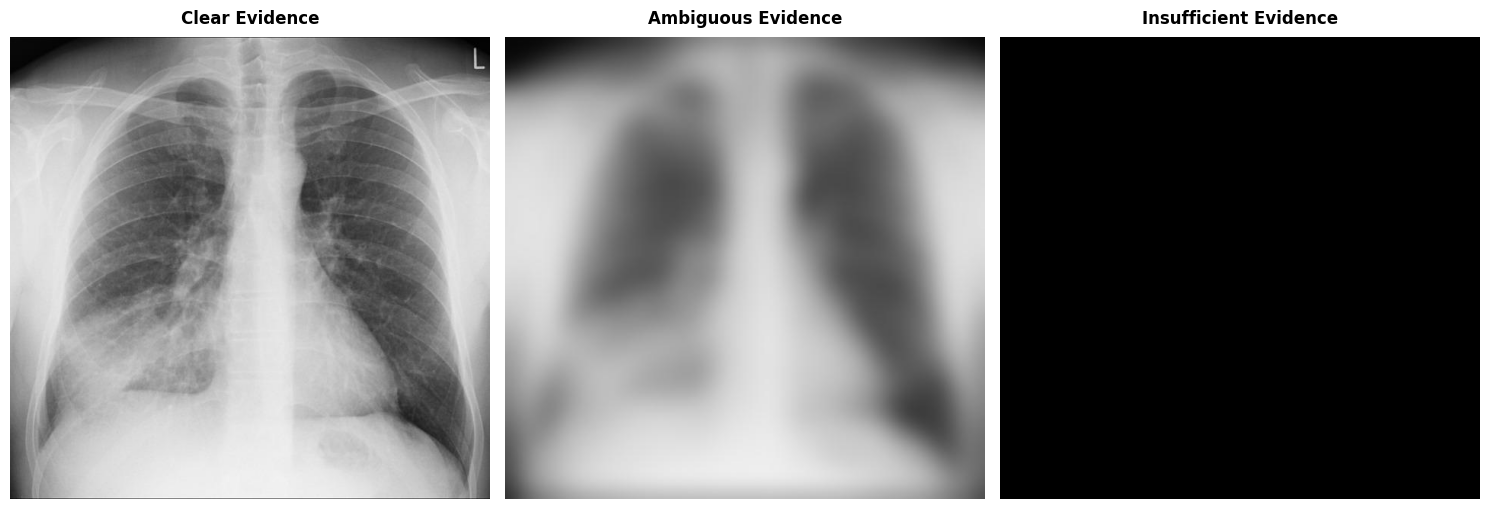

In [11]:
# Instantiate the local paths and compile prompts
my_image = "./chest_xray.jpeg"
pneumonia_prompts = [
    "<image> Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",
    "<image> Briefly describe the diagnosis for this chest X-ray image.",
    "<image> Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly"
]

multimodal_test_set = generate_multimodal_perturbations(source_path=my_image)
display_multimodal_perturbations(multimodal_test_set)


The code block below initializes your execution environment by simultaneously loading backbones for both the **UQLM** and **LM-Polygraph** frameworks under a single, unified master context manager.

You can easily swap out these default targets at any time. Simply replace the model identifier strings—such as changing `"google/paligemma-3b-mix-224"` to another valid Hugging Face repository path, or `"llava"` and `"ollama"` to your preferred model and provider.




In [13]:
# 1. Define the UQLM configurations registry block
uqlm_models = {
    "llava": {
        "provider": "ollama",
        "model_id": "llava"
    }
}

# 2. Initialize the environment passing BOTH framework configurations
uq_engine = setup_uq_environment(
    #polygraph_models="google/paligemma-3b-mix-224",
    #polygraph_is_multimodal=True,
    p_mode="white",
    u_mode="white",
    quant_choice="4bit",
    uqlm_models=uqlm_models,
    polygraph_kwargs={
        "trust_remote_code": True
    },
    auto_install=True
)


🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT

📊 Setting up UQLM [LLAVA] in WHITE-BOX mode...

📥 1. Querying GitHub API and filtering for standard Linux CUDA asset...
🎯 Targeted Asset Matched: 'ollama-linux-amd64.tar.zst'
📥 Downloading package via native curl...
📦 Compressed archive detected. Preparing extraction tools...
📦 Extracting archive directly to system root (/usr)...
✅ Ollama successfully deployed to: /usr/bin/ollama

⚙️ 2. Starting Ollama background daemon...
⏳ 3. Waiting for Ollama server to initialize GPU/CUDA runners...
  [Attempt 1/20] Server is warming up hardware runners, retrying...

🎉 SUCCESS: Ollama is now running locally on Colab VM with full GPU support!
📥 Model 'llava' not found. Starting real-time streaming pull...
📦 [Ollama Download] success...
✅ Successfully pulled weights for local model: 'llava'


/tmp/ipykernel_3475/641428582.py:10: UserWarning: Parameters {'logprobs'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  uq_engine = setup_uq_environment(


🔗 Ollama White-Box instance generated via compatibility layer (http://localhost:11434/v1)

✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES


In [24]:
uq_engine.unload()


🧹 Initiating memory purge for target aliases: ['llava']
  ✅ References cleared for alias: [LLAVA]
  ✨ GPU VRAM cache cleared and synchronized.


---

## **2. Generate Responses and Multimodal UQ Scores**

We implement an asynchronous loop orchestration layer `run_multimodal_uq` that walks through each visual state, injects the image path into our model context, and tracks how the metrics shift under degradation.




In [14]:
# =====================================================================
# 3. HIGH-LEVEL PIPELINE EXECUTION ENGINE
# =====================================================================

async def run_multimodal_uq(
    techniques: List[str],
    test_set: Dict[str, str],
    prompts: List[str],
    uq_context: Any,
    granularity: str = "sequence",
    technique_kwargs: Optional[Dict[str, Dict[str, Any]]] = None,
    **kwargs
) -> Dict[str, pd.DataFrame]:
    """
    Executes a multimodal stress-test matrix over a collection of UQ techniques and prompts.
    Isolates hyperparameter configurations per individual technique via technique_kwargs routing.
    """
    condition_tables_data = {
        cond.replace("_", " ").title(): [] for cond in test_set.keys()
    }

    tech_kwargs_map = technique_kwargs or {}

    for condition, img_path in test_set.items():
        clean_condition = condition.replace("_", " ").title()

        for technique in techniques:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            specific_args = tech_kwargs_map.get(technique, {})
            merged_kwargs = {**kwargs, **specific_args}

            for prompt in prompts:
                try:
                    # L'immagine viene inoltrata; i selettori interni stabiliranno l'attivazione cross-modale
                    result = await evaluate_uncertainty(
                        prompt=prompt,
                        technique_name=technique,
                        granularity=granularity,
                        uq_context=uq_context,
                        image_path=img_path,
                        **merged_kwargs
                    )

                    raw_text = result.get("generated_text", "No response").strip()
                    raw_score = result.get("uncertainty_score", 0.0)

                    if isinstance(raw_score, list):
                        extracted_scores = [float(item["score"]) for item in raw_score if "score" in item]
                        if extracted_scores:
                            mean_score = np.mean(extracted_scores)
                            formatted_score = f"List (Mean: {mean_score:.4f})"
                        else:
                            formatted_score = "[]"
                    else:
                        formatted_score = f"{float(raw_score):.4f}"

                except Exception as e:
                    raw_text = f"Execution Failure: {str(e)}"
                    formatted_score = "N/A"

                condition_tables_data[clean_condition].append({
                    "UQ Technique": technique.replace("polygraph_", "").replace("uqlm_", "").upper(),
                    "Question": prompt.replace("<image>", "").strip(),
                    "Response": raw_text,
                    "Score": formatted_score
                })

    final_dataframes = {}
    for condition, rows in condition_tables_data.items():
        df = pd.DataFrame(rows)
        display(HTML(f"<br><h3 style='color: #1f77b4; font-family: Arial;'>📊 Visual Condition: {condition}</h3>"))
        display(df)
        final_dataframes[condition] = df

    return final_dataframes


---

## **3. Scorer Paradigms & Implementation**

### **A. Sample Diversity Paradigm**



Sample Diversity evaluates a model's confidence by assessing the consistency across $K$ independent, stochastic responses generated at temperature $T > 0$. If a VLM is certain, independent paths converge; if uncertain, they diverge.

* **Black-Box Sample Diversity:** Measures consistency across $K$ generated text responses when internal model access is restricted by providers . This category operates via a shared 3-step framework : first, it samples $K$ outputs $y^{(1)}, \dots, y^{(K)}$ for an input $x$; second, it builds a $K \times K$ similarity matrix $S$ using pairwise textual scores $s(y^{(i)}, y^{(j)})$ (such as NLI or Jaccard); third, it analyzes and aggregates the matrix information to compute the final uncertainty score.
>![Sample Diversity Paradigm](https://drive.google.com/uc?export=view&id=1h-SHUTZvrhHUKtNGFqQl2s_zGrXOj-cT)
* **White-Box Sample Diversity**: Operates at the model's predictive output layer during stochastic generation. Instead of analyzing only the finalized surface text, it extracts and aggregates sequence, word, or token-level probabilities across the $K$ forward passes to measure distributional divergence
>![Sample Diversity Paradigm](https://drive.google.com/uc?export=view&id=1cgYqMflwesud-bK_IAeKQx7QBpSDApKs)




#### **Core Available Techniques**

| Method | Mechanism | Framework | Type |
| --- | --- | --- | --- |
| **NumSemSets** | Clusters $K$ responses using a bi-directional NLI model to count unique semantic sets. | `lm-polygraph` | Black-Box |
| **DegMat** | Constructs a text similarity graph and computes uncertainty via the Graph Laplacian. | `lm-polygraph` | Black-Box |
| **Eccentricity** | Measures the distance of sentence embeddings from the central semantic cluster. | `lm-polygraph` | Black-Box |
| **Semantic Entropy** | Computes Shannon entropy over semantic clusters using token log-likelihoods. | `lm-polygraph` | White-Box |
| **EigenScore** | Evaluates the log-determinant of the covariance matrix derived from the hidden layer embeddings. | `lm-polygraph` | White-Box |
| **Non-Contradiction Prob** | Computes the mean non-contradiction probability estimated by a secondary logical NLI cross-encoder. | `uqlm` | Black-Box |
| **Semantic Sets Conf** | Measures clustering consensus by partitioning $K$ textual outputs via an NLI model without logprobs. | `uqlm` | Black-Box |
| **Semantic Negentropy** | Calculates Shannon entropy over discrete generation clusters derived strictly from textual frequency. | `uqlm` | Black-Box |
| **Monte Carlo Prob** | Aggregates and averages joint token log-probabilities over $K$ separate forward passes. | `uqlm` | White-Box |
| **CoCoA** | Multiplies length-normalized token probabilities by semantic embedding similarities across $K$ samples. | `uqlm` | White-Box |

#### **Paradigm Features**

| Metric Sub-Family | Inference Cost | Image Degradation Resilience |
| :--- | :--- | :--- |
| **Black-Box Diversity** | High ($K$ VLM generations + $O(K^2)$ NLI calls) | **High.** Directly registers when a blurred image creates semantic confusion across sampled texts. |
| **White-Box Diversity** | High ($K$ structural passes extracting logprobs). | **Medium.** Vulnerable to *Language Prior Saturation* if the image becomes completely uninformative. |



#### **Run Sample Diversity Pass**



#### *LM-Polygraph Sample diversity Black-Box Implementation*

Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="lm_polygraph", mode="black", category="Sample diversity")

In [33]:
# 1. Execute LM-Polygraph White-Box Sample Diversity
sample_diversity_blackbox = [
    "polygraph_NumSemSets",
    "polygraph_DegMat",
    "polygraph_Eccentricity"
]

await run_multimodal_uq(
    techniques=sample_diversity_blackbox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,UQ Technique,Question,Response,Score
0,NUMSEMSETS,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,4.0000
1,NUMSEMSETS,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,5.0000
2,NUMSEMSETS,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",tuberculosis,5.0000
3,DEGMAT,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,0.3268
4,DEGMAT,Briefly describe the diagnosis for this chest X-ray image.,tuberculosis,0.1072
5,DEGMAT,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",copd,0.7523
6,ECCENTRICITY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,2.0000
7,ECCENTRICITY,Briefly describe the diagnosis for this chest X-ray image.,lung cancer,1.4142
8,ECCENTRICITY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",copd,2.8284


,UQ Technique,Question,Response,Score
0,NUMSEMSETS,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,1.0000
1,NUMSEMSETS,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,4.0000
2,NUMSEMSETS,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",Obstruction,3.0000
3,DEGMAT,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,0.4239
4,DEGMAT,Briefly describe the diagnosis for this chest X-ray image.,ae,0.5967
5,DEGMAT,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alzheimer's disease,0.6516
6,ECCENTRICITY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,1.7323
7,ECCENTRICITY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,2.0000
8,ECCENTRICITY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alose,2.0008


,UQ Technique,Question,Response,Score
0,NUMSEMSETS,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",unanswerable,3.0000
1,NUMSEMSETS,Briefly describe the diagnosis for this chest X-ray image.,blank image,2.0000
2,NUMSEMSETS,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alzheimer's,3.0000
3,DEGMAT,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,0.4774
4,DEGMAT,Briefly describe the diagnosis for this chest X-ray image.,blank image,0.4212
5,DEGMAT,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",acute respiratory distress syndrome.,0.6870
6,ECCENTRICITY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,1.4144
7,ECCENTRICITY,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,1.0000
8,ECCENTRICITY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alzheimer's,2.2362


#### *LM-Polygraph Sample diversity White-Box Implementation*
Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="lm_polygraph", mode="white", category="Sample diversity")


In [34]:
# 1. Execute LM-Polygraph White-Box Sample Diversity
sample_diversity_whitebox = ["polygraph_EigenScore", "polygraph_SemanticEntropy"]
await run_multimodal_uq(
    techniques=sample_diversity_whitebox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);




/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,UQ Technique,Question,Response,Score
0,EIGENSCORE,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.","yes, pneumonia",7.6359
1,EIGENSCORE,Briefly describe the diagnosis for this chest X-ray image.,lung disease,7.5728
2,EIGENSCORE,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",pneumonia,7.5922
3,SEMANTICENTROPY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,-91.6537
4,SEMANTICENTROPY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,-73.0831
5,SEMANTICENTROPY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",obesity,-64.7999


,UQ Technique,Question,Response,Score
0,EIGENSCORE,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,7.6370
1,EIGENSCORE,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,7.6191
2,EIGENSCORE,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",asthma,7.6784
3,SEMANTICENTROPY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",unanswerable,-81.2707
4,SEMANTICENTROPY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,-61.5357
5,SEMANTICENTROPY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",chronic respiratory disease,-77.9581


,UQ Technique,Question,Response,Score
0,EIGENSCORE,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",unanswerable,7.6250
1,EIGENSCORE,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,7.6143
2,EIGENSCORE,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alzheimer's disease,7.5947
3,SEMANTICENTROPY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",unanswerable,-62.6699
4,SEMANTICENTROPY,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,-70.9730
5,SEMANTICENTROPY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",chronic lung disease,-69.8030


#### *UQLM Sample diversity Black-Box Implementation*
Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="uqlm", mode="black", category="Sample diversity")

In [19]:
uqlm_blackbox_techniques = [
    "uqlm_noncontradiction",
    "uqlm_semantic_sets_confidence",
    "uqlm_semantic_negentropy"
]

await run_multimodal_uq(
    techniques=uqlm_blackbox_techniques,
    test_set = multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence",
);

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

,UQ Technique,Question,Response,Score
0,NONCONTRADICTION,Is there pneumonia in this chest X-ray? Answer...,The image you've provided is an X-ray of a hum...,0.8541
1,NONCONTRADICTION,Briefly describe the diagnosis for this chest ...,"This is an X-ray of a human torso, specificall...",0.6922
2,NONCONTRADICTION,Based on the pulmonary opacities and costophre...,The image shows an X-ray of a person's chest. ...,0.9810
3,SEMANTIC_SETS_CONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,The image shows a chest X-ray film placed with...,0.4000
4,SEMANTIC_SETS_CONFIDENCE,Briefly describe the diagnosis for this chest ...,"The image you've shown is of an X-ray, specifi...",1.0000
5,SEMANTIC_SETS_CONFIDENCE,Based on the pulmonary opacities and costophre...,The image you provided shows an anatomical che...,1.0000
6,SEMANTIC_NEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,The image you've provided is an X-ray of a hum...,0.3978
7,SEMANTIC_NEGENTROPY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be an X-r...,0.5158
8,SEMANTIC_NEGENTROPY,Based on the pulmonary opacities and costophre...,The image you've provided displays a lateral-c...,0.7485


,UQ Technique,Question,Response,Score
0,NONCONTRADICTION,Is there pneumonia in this chest X-ray? Answer...,The image you've provided is an X-ray of a per...,0.9968
1,NONCONTRADICTION,Briefly describe the diagnosis for this chest ...,"A black and white X-ray image is displayed, sh...",0.9899
2,NONCONTRADICTION,Based on the pulmonary opacities and costophre...,The image depicts an X-ray of a human chest. T...,0.9114
3,SEMANTIC_SETS_CONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be an X-r...,0.4000
4,SEMANTIC_SETS_CONFIDENCE,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be an X-r...,0.6000
5,SEMANTIC_SETS_CONFIDENCE,Based on the pulmonary opacities and costophre...,"The image shows a set of X-rays, focusing main...",0.8000
6,SEMANTIC_NEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,The image shows a patient's chest X-ray with a...,0.3960
7,SEMANTIC_NEGENTROPY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be an X-r...,0.4562
8,SEMANTIC_NEGENTROPY,Based on the pulmonary opacities and costophre...,The image provided appears to be a chest X-ray...,0.5158


,UQ Technique,Question,Response,Score
0,NONCONTRADICTION,Is there pneumonia in this chest X-ray? Answer...,The image appears to be a black and white X-ra...,0.9055
1,NONCONTRADICTION,Briefly describe the diagnosis for this chest ...,The image you provided is too small and blurry...,0.9941
2,NONCONTRADICTION,Based on the pulmonary opacities and costophre...,The image you've provided is very small and of...,0.9966
3,SEMANTIC_SETS_CONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,The image shows a black and white chest radiog...,0.4000
4,SEMANTIC_SETS_CONFIDENCE,Briefly describe the diagnosis for this chest ...,The image shows a black and white representati...,0.2000
5,SEMANTIC_SETS_CONFIDENCE,Based on the pulmonary opacities and costophre...,"The image you've provided is black and white, ...",0.6000
6,SEMANTIC_NEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,I'm unable to analyze medical images as part o...,0.2993
7,SEMANTIC_NEGENTROPY,Briefly describe the diagnosis for this chest ...,The image appears to be a cropped portion of a...,0.2684
8,SEMANTIC_NEGENTROPY,Based on the pulmonary opacities and costophre...,The image appears to be a digital X-ray or CT ...,0.4666


#### *UQLM Sample diversity White-Box Implementation*
Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="uqlm", mode="white", category="Sample diversity")

In [20]:
# 2. Execute UQLM White-Box Sample Diversity
uqlm_whitebox_techniques = ["uqlm_monte_carlo_probability", "uqlm_consistency_and_confidence"]
await run_multimodal_uq(
    techniques=uqlm_whitebox_techniques,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);

Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

...

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

,UQ Technique,Question,Response,Score
0,MONTE_CARLO_PROBABILITY,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be an X-r...,0.3114
1,MONTE_CARLO_PROBABILITY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a medi...,0.3009
2,MONTE_CARLO_PROBABILITY,Based on the pulmonary opacities and costophre...,The image you've provided is an X-ray film of ...,0.3295
3,CONSISTENCY_AND_CONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,This is an X-ray image of a human chest. The i...,0.2858
4,CONSISTENCY_AND_CONFIDENCE,Briefly describe the diagnosis for this chest ...,The provided image shows a side view of human ...,0.2704
5,CONSISTENCY_AND_CONFIDENCE,Based on the pulmonary opacities and costophre...,The image shows a chest X-ray with several are...,0.3881


,UQ Technique,Question,Response,Score
0,MONTE_CARLO_PROBABILITY,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be an X-r...,0.3285
1,MONTE_CARLO_PROBABILITY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a CT s...,0.3047
2,MONTE_CARLO_PROBABILITY,Based on the pulmonary opacities and costophre...,The image appears to be a chest X-ray showing ...,0.3739
3,CONSISTENCY_AND_CONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,"No, there is no evidence of pneumonia on the p...",0.4363
4,CONSISTENCY_AND_CONFIDENCE,Briefly describe the diagnosis for this chest ...,The image you've shared appears to be a chest ...,0.3425
5,CONSISTENCY_AND_CONFIDENCE,Based on the pulmonary opacities and costophre...,The image you've provided appears to be an X-r...,0.3697


,UQ Technique,Question,Response,Score
0,MONTE_CARLO_PROBABILITY,Is there pneumonia in this chest X-ray? Answer...,"Based on the image provided, it appears to be ...",0.3372
1,MONTE_CARLO_PROBABILITY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a ches...,0.3455
2,MONTE_CARLO_PROBABILITY,Based on the pulmonary opacities and costophre...,The image appears to show a view of a chest X-...,0.3331
3,CONSISTENCY_AND_CONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be a blac...,0.3489
4,CONSISTENCY_AND_CONFIDENCE,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be an X-r...,0.4269
5,CONSISTENCY_AND_CONFIDENCE,Based on the pulmonary opacities and costophre...,The image you've provided appears to show a me...,0.4132


### **📑 Observations**


#### **The Core Multimodal Anomalies**

The empirical data highlights two foundational bottlenecks in text-derived uncertainty quantification for Vision-Language Models:

* **The Fluent Hallucination Blindspot (Low Calibration):** During the **Clear Evidence** phase, the model generates completely incorrect diagnoses (e.g., answering **"tuberculosis"** or **"copd"** for a chest radiograph). Because the language decoder outputs these errors with high grammatical fluency, standard text-consistency estimators are easily tricked into logging dangerously low uncertainty.
* **The Language Prior Refusal Trap (Poor Visual Alignment):** When shifting from **Ambiguous** to **Insufficient Evidence** (total visual blackout), the model collapses into rigid textual fallback loops (stochastically repeating words like *"unanswerable"* or *"blank image"*). This artificial text consensus forces discrete entropy and clustering metrics to **drop** their uncertainty scores, misinterpreting a blind model's robotic refusal loop as authentic confidence.

---

#### **Head-to-Head Comparison By Technique**
#### Graph Matrix Overlap vs. Logical Contradiction

* **`polygraph_DegMat`:** Shows strong visual alignment during intermediate degradation, with uncertainty climbing steadily under Gaussian blur (e.g., from **0.1072** up to **0.5967** on short descriptions). However, it exhibits poor accuracy calibration in the clear phase, registering a highly confident **0.1072** for a completely false *"tuberculosis"* hallucination.
* **`uqlm_noncontradiction`:** Outperforms `DegMat` in both calibration and visual alignment. It successfully flags the clear-phase hallucinations with a high uncertainty of **0.9810**, peaks cleanly at **0.9968** under blur, and successfully resists the Language Prior Trap during total blackout by holding its ground at **0.9941**.

##### Discrete Set Counters vs. Cluster Confidence

* **`polygraph_NumSemSets`:** Measures raw semantic bin counts. It maps clear-phase confusion with a high score of **5.0000**, but falls victim to the Refusal Trap during complete visual starvation—collapsing down to **2.0000** because the text outputs converge on uniform fallback loops.
* **`uqlm_semantic_sets_confidence`:** Measures clustering consensus (where lower values signify higher uncertainty). It exhibits poor calibration during clear evidence, logging a maximum confidence score of **1.0000** for flagrant errors. However, it tracks total visual starvation better than `NumSemSets`, dropping its confidence score to **0.2000** when the model repeatedly outputs *"blank image"*.

##### Log-Likelihood Entropy vs. Normalized Textual Negentropy

* **`polygraph_SemanticEntropy`:** Operates on unnormalized token log-probabilities. It reacts erratically across the degradation loop (**-91.6537** $\rightarrow$ **-61.5357** $\rightarrow$ **-70.9730**), showing poor linear alignment because its mathematical bounds are dominated by linguistic fluency weights rather than cross-modal grounding.
* **`uqlm_semantic_negentropy`:** Provides a much cleaner, normalized black-box entropy proxy. However, it is heavily vulnerable to the Refusal Trap under complete visual failure, dropping its logged uncertainty from **0.5158** (Ambiguous) down to **0.2684** (Insufficient) when the model's answers converge on standard fallback text.

##### Hidden-State Covariance vs. Single-Pass Token Probability

* **`polygraph_EigenScore`:** Completely fails as a multimodal tracking metric. It remains entirely saturated and static (**7.63** $\rightarrow$ **7.61**) across all visual states, as hidden layer residuals are completely blind to encoder-level visual starvation.
* **`uqlm_monte_carlo_probability` & `consistency_and_confidence`:** These white-box token-probability aggregators remain highly compressed and insulated from chaotic score jumps, maintaining a tight, conservative window between **0.2704** and **0.4363** across all phases. While safe from noise, they display low overall resolution for tracking gradual visual context decay.


---

### **B. Information-Based Paradigm**

Information-Based UQ evaluates model confidence by extracting token probabilities, structural weights, or sequence likelihoods.

* **White-Box Information UQ**: Runs optimally on exactly one deterministic forward pass ($K = 1$). It operates efficiently by parsing the internal token logit distribution or hidden layer state residuals along the generated predictive path.
>![Sample Diversity Paradigm](https://drive.google.com/uc?export=view&id=1epOsaYB5NFXrOb73JRC9pLp71ZMnWJD5)


* **Black-Box Information UQ:** Functions as a hybrid proxy; because it lacks access to logits, it must sample the model stochastically ($K > 1$) to empirically reconstruct sequence likelihood based on surface text generation frequency.
>![Sample Diversity Paradigm](https://drive.google.com/uc?export=view&id=1n0XmNRXsnaINZItCSQEbcx-FR12zKRMW)


#### **Core Available Techniques**

| Method | Mechanism | Framework | Type |
| --- | --- | --- | --- |
| **LabelProb** | Approximates sequence probability via the empirical frequency of the identical string across samples. | `lm-polygraph` | Black-Box |
| **Max Sequence Prob** | Computes the unnormalized joint cumulative log-probability of the single chosen token path. | `lm-polygraph` | White-Box |
| **Mean Token Entropy** | Calculates the average Shannon entropy across the entire vocabulary logit distribution for every token. | `lm-polygraph` | White-Box |
| **Attention Score** | Extracts and aggregates internal layer-wise attention weights across cross-modal execution paths. | `lm-polygraph` | White-Box |
| **Sequence Probability** | Computes the joint token log-likelihood over the sequence, with optional length-normalization. | `uqlm` | White-Box |
| **Probability Margin** | Measures the average numerical distance between the top-1 predicted token logit and the runner-up top-2 logit. | `uqlm` | White-Box |
| **Mean Token Negentropy** | Computes the negative Shannon entropy over the vocabulary distribution to provide a confidence index. | `uqlm` | White-Box |




#### **Paradigm Features**

| Metric Sub-Family | Core Operational Mechanism | Inference Cost | Image Degradation Resilience |
|---|---|---|---|
| **Logit-Space Information** | Tracks vocabulary margins or cumulative sequence probabilities (e.g., `MaximumSequenceProbability`). | Minimal (1 Forward Pass). | **Low.** Suffers from extreme overconfidence when the decoder outputs fluent hallucinations driven by language priors. |
| **Attention-Space Information** | Directly probes cross-attention kernel maps (`polygraph_attention`) matching text generation to image patches. | Minimal (1 Forward Pass). | **Maximum.** Captures the exact structural failure when decoded language tokens fail to find spatial grounding in the image. |

#### **Run Information-Based Pass**




#### *LM_Polygraph Informaation-Based Black-Box Implementation*
Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="lm-polygraph", mode="black", category="Information-based")

In [35]:
# 1. Execute LM-Polygraph Hybrid Black-Box Information Metrics
information_based_blackbox = ["polygraph_LabelProb"]
await run_multimodal_uq(
    techniques=information_based_blackbox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,UQ Technique,Question,Response,Score
0,LABELPROB,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,0.5000
1,LABELPROB,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,0.4000
2,LABELPROB,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alzheimer's,0.7000


,UQ Technique,Question,Response,Score
0,LABELPROB,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,0.4000
1,LABELPROB,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,0.7000
2,LABELPROB,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",pneumonia,0.8000


,UQ Technique,Question,Response,Score
0,LABELPROB,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",unanswerable,0.3000
1,LABELPROB,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,0.1000
2,LABELPROB,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",obesity,0.7000


#### *LM_Polygraph Informaation-Based White-Box Implementation*
Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="lm-polygraph", mode="white", category="Information-based")

In [36]:
information_based_whitebox = ["polygraph_attention"]


await run_multimodal_uq(
    techniques=information_based_whitebox,
    test_set = multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,UQ Technique,Question,Response,Score
0,ATTENTION,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,1653.7112
1,ATTENTION,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,1603.1955
2,ATTENTION,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",Alveolmonary disease.,1716.1512


,UQ Technique,Question,Response,Score
0,ATTENTION,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,1617.5682
1,ATTENTION,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,1571.4148
2,ATTENTION,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",epilepsy,1658.9017


,UQ Technique,Question,Response,Score
0,ATTENTION,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,1711.9583
1,ATTENTION,Briefly describe the diagnosis for this chest X-ray image.,blank image,1649.7738
2,ATTENTION,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",pneumonia.,1739.4162


In [37]:
information_based_whitebox = ["polygraph_MaximumSequenceProbability", "polygraph_MeanTokenEntropy"]
await run_multimodal_uq(
    techniques=information_based_whitebox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,UQ Technique,Question,Response,Score
0,MAXIMUMSEQUENCEPROBABILITY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,-40.2790
1,MAXIMUMSEQUENCEPROBABILITY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,-64.3080
2,MAXIMUMSEQUENCEPROBABILITY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",chronic lung disease,-67.8460
3,MEANTOKENENTROPY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,-60281016320.0000
4,MEANTOKENENTROPY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,-2417917427712.0000
5,MEANTOKENENTROPY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",pneumonia.,-297987211264.0000


,UQ Technique,Question,Response,Score
0,MAXIMUMSEQUENCEPROBABILITY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,-40.2790
1,MAXIMUMSEQUENCEPROBABILITY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,-60.9821
2,MAXIMUMSEQUENCEPROBABILITY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",chronic respiratory disease,-71.2500
3,MEANTOKENENTROPY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,-42438811648.0000
4,MEANTOKENENTROPY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,-1098226008064.0000
5,MEANTOKENENTROPY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",Asbestos.,-2747846144.0000


,UQ Technique,Question,Response,Score
0,MAXIMUMSEQUENCEPROBABILITY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,-39.4085
1,MAXIMUMSEQUENCEPROBABILITY,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,-75.5357
2,MAXIMUMSEQUENCEPROBABILITY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",Obstructive pneumonia.,-98.5045
3,MEANTOKENENTROPY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",unanswerable,-11673086976.0000
4,MEANTOKENENTROPY,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,-5517813760.0000
5,MEANTOKENENTROPY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alzheimer's,-4110428160.0000


#### *UQLM Informaation-Based White-Box Implementation*
Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="uqlm", mode="white", category="Information-based")

In [21]:
# 3. Execute UQLM White-Box Single-Pass Metrics
uqlm_info_whitebox = ["uqlm_sequence_probability", "uqlm_probability_margin", "uqlm_mean_token_negentropy"]
await run_multimodal_uq(
    techniques=uqlm_info_whitebox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);

Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

Output()

...

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/scorers/shortform/white_box.py:227: UQLMBetaWarning: Scorers based on top_logprobs ('mean_token_negentropy','min_token_negentropy','probability_margin') is in beta. Please use with caution as it may change in future releases.
  beta_warning("Scorers based on top_logprobs ('mean_token_negentropy','min_token_negentropy','probability_margin') is in beta. Please use with caution as it may change in future releases.")


,UQ Technique,Question,Response,Score
0,SEQUENCE_PROBABILITY,Is there pneumonia in this chest X-ray? Answer...,"Yes, there is evidence of pneumonia visible on...",0.4532
1,SEQUENCE_PROBABILITY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a medi...,0.4264
2,SEQUENCE_PROBABILITY,Based on the pulmonary opacities and costophre...,The image you've provided is an X-ray of a hum...,0.4616
3,PROBABILITY_MARGIN,Is there pneumonia in this chest X-ray? Answer...,"Based on the image provided, it appears to be ...",0.6200
4,PROBABILITY_MARGIN,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be an X-r...,0.5431
5,PROBABILITY_MARGIN,Based on the pulmonary opacities and costophre...,The image shows a lateral chest X-ray of an in...,0.5673
6,MEAN_TOKEN_NEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,The image shows an X-ray of a human chest with...,0.6600
7,MEAN_TOKEN_NEGENTROPY,Briefly describe the diagnosis for this chest ...,This is an X-ray image of a human chest. The X...,0.6395
8,MEAN_TOKEN_NEGENTROPY,Based on the pulmonary opacities and costophre...,The image you've provided appears to show an X...,0.6591


,UQ Technique,Question,Response,Score
0,SEQUENCE_PROBABILITY,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to show a ch...,0.3870
1,SEQUENCE_PROBABILITY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be an X-r...,0.4363
2,SEQUENCE_PROBABILITY,Based on the pulmonary opacities and costophre...,The image appears to show an X-ray of a chest ...,0.4912
3,PROBABILITY_MARGIN,Is there pneumonia in this chest X-ray? Answer...,"Yes, there is evidence of a condition that loo...",0.5665
4,PROBABILITY_MARGIN,Briefly describe the diagnosis for this chest ...,The image appears to be an X-ray of a human to...,0.5674
5,PROBABILITY_MARGIN,Based on the pulmonary opacities and costophre...,This appears to be a medical X-ray image. The ...,0.4994
6,MEAN_TOKEN_NEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be a medi...,0.6557
7,MEAN_TOKEN_NEGENTROPY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a medi...,0.6807
8,MEAN_TOKEN_NEGENTROPY,Based on the pulmonary opacities and costophre...,The image you've provided appears to show an X...,0.6697


,UQ Technique,Question,Response,Score
0,SEQUENCE_PROBABILITY,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be a ches...,0.5503
1,SEQUENCE_PROBABILITY,Briefly describe the diagnosis for this chest ...,The image you've provided is a black and white...,0.4653
2,SEQUENCE_PROBABILITY,Based on the pulmonary opacities and costophre...,The image appears to show a side view of an X-...,0.4227
3,PROBABILITY_MARGIN,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be a blac...,0.5737
4,PROBABILITY_MARGIN,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a text...,0.6265
5,PROBABILITY_MARGIN,Based on the pulmonary opacities and costophre...,The image you've provided appears to be an X-r...,0.5414
6,MEAN_TOKEN_NEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,The image you provided appears to be a black a...,0.5999
7,MEAN_TOKEN_NEGENTROPY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a ches...,0.7076
8,MEAN_TOKEN_NEGENTROPY,Based on the pulmonary opacities and costophre...,The image you've provided is a chest X-ray. An...,0.6242


### **📑 Observations**





### **Macro Insights: The Information-Space Failures**

* **The Fluent Hallucination Blindspot (Poor Calibration):** Logit-space metrics demonstrate a profound lack of calibration during clinical hallucinations. When the model looks at a clear chest X-ray and confidently hallucinates **"alzheimer's"** or **"chronic lung disease"**, logit metrics output highly confident bounds because the output text is grammatically fluent and predictable within the text decoder.
* **The Language Prior Saturation Inversion (Poor Visual Alignment):** When shifting to *Insufficient Evidence* (complete black canvas), almost all logit-derived metrics suffer from trendline inversion. The model detaches from the vision encoder and drops into repetitive linguistic fallback loops (*"unanswerable"*). Because these standard phrases contain highly predictable tokens, logit probabilities spike, causing metrics to register **falsely low uncertainty** during total visual failure.

---

### **Head-to-Head Comparisons**
#### **`polygraph_attention` vs. `uqlm_sequence_probability`**

* **`polygraph_attention` [Optimal Alignment]:** This white-box technique emerges as the only metric that scales linearly with image decay. By probing internal layer-wise weights, it bypasses surface text logits. It successfully tracks when the language decoder starves for visual grounding, peaking at its absolute highest boundary  during total visual blackout, and successfully flagging bizarre hallucinations like *"epilepsy"* under blur.
* **`uqlm_sequence_probability` [Severe Inversion]:** This metric is entirely blinded by the text decoder's autonomy. Under total visual starvation (*Insufficient Evidence*), its score jumps to a highly confident  (higher than its clear-evidence baseline) simply because the model outputs a brief, grammatically crisp fallback phrase.

#### **`polygraph_MaximumSequenceProbability` vs. `uqlm_probability_margin`**

* **`polygraph_MaximumSequenceProbability` [Unnormalized Rigidity]:** This metric fails to reflect visual changes on brief answers, remaining completely static at the same value across both Clear and Ambiguous states for binary questions. Under total visual failure, it collapses to  on descriptive prompts, rendering threshold calibration highly unstable due to its unnormalized scale.
* **`uqlm_probability_margin` [Prior Saturation]:** While bounded and cleaner to interpret, this metric fails to adjust dynamically to visual context decay.  When the model operates blindly on language priors during starvation, the distance between the top-1 and top-2 tokens remains artificially wide, signaling high confidence over an uninformative pitch-black asset.

#### **`polygraph_MeanTokenEntropy` vs. `uqlm_mean_token_negentropy`**

* **`polygraph_MeanTokenEntropy` [Scale Distortion]:** This metric suffers from extreme, unnormalized exponential scaling values. This structural instability makes it virtually impossible to deploy within a linear automated gate or risk-management pipeline without heavy non-linear normalization.
* **`uqlm_mean_token_negentropy` [Linguistic Domination]:** This black-box proxy normalizes vocabulary distributions cleanly, but is entirely dominated by the language model's pre-trained weights. It rewards the model's blind, incorrect responses with high confidence indexes, making it highly dangerous for multimodal safety enforcement.

#### **`polygraph_LabelProb` [Empirical Proxy Failure]**

* This hybrid technique attempts to empirically approximate sequence probabilities without logit access. It completely miscalibrates under visual noise: it logs a highly confident for a flagrant, absurd hallucination (*"alzheimer's"* on a chest X-ray) during clear evidence, and drops to a low  on standard refusal text during starvation, exhibiting total cross-modal misalignment.

## **Claim=????**

## **C. Density Based**

In [ ]:
CALIBRATION_SET = [
    {"image": "./chest_xray.jpeg", "prompt": "Analyze this chest X-ray."},
    # Aggiungi qui gli altri percorsi di immagini sane (In-Distribution)
]

# Estraiamo il modello e il processore attuali dal contesto di uq_engine
visual_model = uq_engine.polygraph_models["default"]
model = visual_model.model
processor = visual_model.processor_visual

# =====================================================================
# 2. ESTRAZIONE DEGLI EMBEDDINGS DAL VLM
# =====================================================================
all_embeddings = []
model.eval()

print("⚙️ Extracting Multimodal Embeddings for Mahalanobis Calibration...")

with torch.no_grad():
    for sample in CALIBRATION_SET:
        if not os.path.exists(sample["image"]):
            print(f"⚠️ Immagine non trovata, la salto: {sample['image']}")
            continue

        raw_image = Image.open(sample["image"]).convert("RGB")

        # Generiamo i tensori di input multimodali nativi
        inputs = processor(text=sample["prompt"], images=raw_image, return_tensors="pt").to(model.device)
        outputs = model(**inputs, output_hidden_states=True)

        # Estraiamo gli hidden states dell'ultimo layer dell'ultimo token
        last_hidden = outputs.hidden_states[-1][:, -1, :].cpu().numpy()
        all_embeddings.append(last_hidden)

# =====================================================================
# 3. CALCOLO DELLA COVARIANZA CON UNPACKING DELLA TUPLA
# =====================================================================
# Uniamo gli vettori estratti in un'unica matrice
train_features = np.vstack(all_embeddings)
centroids = np.mean(train_features, axis=0, keepdims=True)

# Convertiamo in PyTorch Tensor per alimentare la funzione nativa di lm-polygraph
centroids_tensor = torch.from_numpy(centroids).float()
train_features_tensor = torch.from_numpy(train_features).float()

print("🧮 Calculating inverse covariance matrix via lm-polygraph native CUDA operation...")

# Eseguiamo il calcolo e spacchettiamo la tupla (sigma_inv, background_sigma_inv)
sigma_inv_tensor, background_sigma_inv_tensor = compute_inv_covariance(centroids_tensor, train_features_tensor)

# Riconvertiamo i singoli tensori estratti in array NumPy
centroids_numpy = centroids_tensor.cpu().numpy()
sigma_inv_numpy = sigma_inv_tensor.cpu().numpy()

# 🎯 FIX DEFINITIVO ANTI-CRASH: Controlla se il background è un vero Tensor o un semplice float
if isinstance(background_sigma_inv_tensor, torch.Tensor):
    background_sigma_inv_numpy = background_sigma_inv_tensor.cpu().numpy()
else:
    background_sigma_inv_numpy = background_sigma_inv_tensor  # Rimane il float nativo (es. 0.0)

# =====================================================================
# 4. SALVATAGGIO DEI PARAMETRI FINALI
# =====================================================================
params_dict = {
    "centroids": centroids_numpy,
    "sigma_inv": sigma_inv_numpy,
    "background_sigma_inv": background_sigma_inv_numpy
}

parameters_file_path = "./mahalanobis_params.pkl"
with open(parameters_file_path, "wb") as f:
    pickle.dump(params_dict, f)

print(f"\n✅ File di calibrazione generato con successo e salvato in: {parameters_file_path}")

In [ ]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

# 3. Execute UQLM White-Box Single-Pass Metrics
polygraph_density_whitebox = ["polygraph_MahalanobisDistanceSeq"]
await run_multimodal_uq(
    techniques=polygraph_density_whitebox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);



### **C. Ensemble Uncertainty Quantification (UQ)**

Ensemble scorers provide more robust and calibrated uncertainty estimates by combining diverse statistical perspectives from multiple individual estimators. By integrating methods such as semantic overlap and raw token probabilities, ensembles significantly reduce calibration error on complex, open-ended tasks. This architectural approach offers high flexibility and customizability, allowing you to tailor the ensemble's bias to specific clinical use cases by combining any mix of black-box and white-box scorers. Note that the ensemble inherits the latency and cost of all its component scorers.

#### **How it Works**

The core functioning of an ensemble scorer relies on a mathematical framework that aggregates individual results into a unified confidence metric. Given a set of $n$ component scorers with individual scores $s_k(y_i)$ and their corresponding normalized weights $w_k$, where:

$$\sum_{k=1}^n w_k = 1$$

The finalized ensemble prediction uncertainty score for a generated output $y_i$ is formally calculated as:

$$\text{Ensemble}(y_i) = \sum_{k=1}^n w_k \cdot s_k(y_i)$$

#### **Optimization Prerequisites**

The optimization runtime uses a labeled calibration dataset to navigate the hyperparameter landscape and automatically discover the optimal combination of weights $w_k$. To successfully tune the ensemble, you require:

* **Labeled Calibration Data:** A training partition (`train_df`) containing explicit input questions paired with their definitive **ground-truth answers**.
* **A Grader Function (`grader_function`):** A custom programmatic rule (such as case-insensitive substring matching or semantic alignment) used by the optimization engine to dynamically evaluate whether the model's sampled generations are correct or incorrect against the ground-truth annotations.

> ⚠️ **Crucial Architectural Constraints for Multimodal Setup:**
> * **Exclusive to UQLM:** Structural multi-scorer generalized ensembles are strictly supported by the `uqlm` backend framework. The `lm_polygraph` backend does not natively support joint Optuna weight tuning or ensemble blending for vision-language inputs.
> * **No LLM-as-a-Judge Components:** Unlike pure textual pipelines, **LLM-as-a-Judge metrics are not available** in this multimodal workflow due to context parsing limitations over interleaved visual tokens. The ensemble is composed strictly of black-box and white-box scorers.
>
>


>![Ensamble](https://drive.google.com/uc?export=view&id=1RFwZaakt3U30gAi0uDHi9-Ugji-M-jt0)


#### **Custom Grader Function**

The tuning engine requires a deterministic rule to verify output accuracy during optimization trials. Because Vision-Language Models (VLMs) often generate verbose or conversational answers, exact string matching (`==`) fails.

* **The Grader Contract:** The function must accept `(response, answer)` and strictly return `True` if the output is correct relative to the ground-truth label, and `False` otherwise.

We implement a case-insensitive symmetric substring match to eliminate false negatives caused by conversational VLM padding.




In [14]:
import os
import base64
from typing import List, Union, Optional, Any
from langchain_core.messages import HumanMessage
# =====================================================================
# 🎯 ENSEMBLE GRADER EVALUATION RULE
# =====================================================================
def grade_response(response: str, answer: str) -> bool:
    """
    Executes a symmetric case-insensitive substring verification matching rule.
    Prevents false negatives caused by conversational VLM verbose responses.
    """
    resp_clean = str(response).strip().lower()
    ans_clean = str(answer).strip().lower()
    return ans_clean in resp_clean or resp_clean in ans_clean



### **Training Phase: Calibration & Joint Tuning**

The training routine uses a labeled calibration dataset to map the decision space. It is divided into two operational steps: loading the target dataset data structures, and executing the asynchronous Optuna optimization engine.

#### **Step 1: Multimodal Dataset Loading & Partitioning**

We load clinical VQA samples directly from the Hugging Face Hub. The data engine detects visual assets dynamically, converts them to stable base64 memory encodings, and yields strictly isolated, leakage-free calibration (Train) and evaluation (Test) pools.

You can use your own datset by modyfing the `path` variable

*Note:*  We load just 40 samples for computational efficiency pf the tutorial but you need > 1000 samples for a better calibration of the weights.

In [17]:
gc.collect()
torch.cuda.empty_cache()

# Load clinical partitions (e.g., flaviagiammarino/vqa-rad) using the native hybrid processing engine
train_df, test_df = prepare_dataset(
    path="flaviagiammarino/vqa-rad",
    max_samples=40,
    test_size=0.33,
    random_state=42
)

# Isolate holdout testing matrices for downstream validation phases
multimodal_test_set = test_df


⏳ Loading clinical dataset directly from Hugging Face Hub (flaviagiammarino/vqa-rad)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

📊 Dataset processing complete via native Hybrid Engine!
   └── Operational Mode: MULTIMODAL (Vision-Language)
   └── 📈 Train size (Calibration Fitting Pool): 26 samples
   └── 📉 Test size (Holdout Evaluation Pool):  14 samples





#### **Step 2: Joint Ensemble Tuning & Hyperparameter Optimization via Optuna**

To maximize the reliability of our multimodal ensemble, we cannot rely on uniform or arbitrary weight distributions. Instead, `uqlm` provides a native `.tune()` engine powered by **Optuna** to execute an automated search over our calibration dataset (`train_df`).

This optimization phase simultaneously calibrates two critical operational variables:

1. **Scorer Weights ($w_k$):** The relative importance and mathematical scaling assigned to each active metric (`semantic_sets_confidence`, `sequence_probability`, `exact_match`).
You can select your own combination of black-box and white-box scorers.

2. **Operational Decision Threshold:** The specific confidence boundary below which the model's response is flagged as untrustworthy or rejected.

##### **Understanding the Core Optimization Parameters:**

* **`weights_objective`** *(str, default=`'roc_auc'`)*: Sets the mathematical objective function utilized by Optuna to discover the optimal scorer weight distribution. You can pass any of the following metrics:
    * `'roc_auc'`: Optimizes for the best discrimination capability across all potential decision cutoffs (ideal for continuous calibration).
    * `'log_loss'` / `'brier_score'`: Minimizes probabilistic error, forcing the uncertainty scores to reflect true error probabilities.
    * `'average_precision'`: Maximizes the area under the precision-recall curve, highlighting performance on minority target classes.
    * `'accuracy_score'` / `'balanced_accuracy_score'` / `'fbeta_score'`: Optimizes weights directly against hard, discrete decision boundaries.
* **`thresh_objective`** *(str, default=`'fbeta_score'`)*: Specifies the evaluation metric used to isolate the operational cutoff boundary via an internal grid search. The supported discrete metrics are:
    * `'fbeta_score'`: Balances precision and recall (highly customizable for balancing clinical sensitivity and specificity).
    * `'accuracy_score'`: Maximizes the absolute percentage of correctly classified instances.
    * `'balanced_accuracy_score'`: Adjusts accuracy to account for severe class imbalances in the dataset.
* **`thresh_bounds`** *(tuple of floats, default=`(0, 1)`)*: A tuple of floats defining the bounded search domain for the optimization grid search.
* **`num_responses=5`**: Instructs the engine to generate 5 independent sampled responses per calibration prompt. This generation pool is required by white-box and black-box consistency scorers (like `semantic_sets`) to calculate response entropy and cluster variance.
* **`n_trials=25`**: The total number of black-box optimization iterations Optuna will run to navigate the hyperparameter space and converge on the global maximum.




In [18]:
# Scorer Components
uqlm_scorers = ["semantic_sets_confidence", "sequence_probability", "exact_match"]

In [19]:
from uqlm import UQEnsemble

# Map calibration entries into LangChain compatible VLM message inputs via helper utility
tune_prompts = [
    _prepare_uqlm_execution_prompts(
        prompts_list=[f"<image>\n{row['question']}"],
        image_base64=row["image_base64"]
    )[0]
    for _, row in train_df.iterrows()
]

tune_answers = train_df["answer"].tolist()

# Extract active driver instance from the central engine environment context
base_llm = list(uq_engine.langchain_llms.values())[0]

# Downscale the NLI engine to DeBERTa-v3-base to optimize VRAM utilization on local GPU
uqe_tuning = UQEnsemble(
    llm=base_llm,
    max_calls_per_min=1000,
    scorers=uqlm_scorers,
    device="cpu",
    nli_model_name="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
)

print(f"🔄 Executing joint optimization over {len(tune_prompts)} calibration samples...")

# Launch the weight and acceptance threshold search landscape guided by accuracy matching rules
tune_results = await uqe_tuning.tune(
    prompts=tune_prompts,
    ground_truth_answers=tune_answers,
    grader_function=grade_response,
    num_responses=5,
    weights_objective="accuracy_score",
    thresh_objective="accuracy_score",
    n_trials=25
)

# Extract optimized configuration boundaries to deploy during evaluation
OPTIMIZED_WEIGHTS = uqe_tuning.weights
OPTIMAL_THRESHOLD = uqe_tuning.thresh

print("\n🏆 MULTIMODAL ENSEMBLE TUNING SUCCESSFUL!")
print(f"Optimized Scorer Weights: {OPTIMIZED_WEIGHTS}")
print(f"Calibrated Threshold:     {OPTIMAL_THRESHOLD}")

🤖 Generation                                                                                                    
    - Generating responses...                                    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26/26   0:04:00
    - Generating candidate responses (5 per prompt)...           ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130/130 0:09:09
                                                                                                                   
  📈 Scoring                                                                                                       
    - Scoring responses with semantic clustering...              ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26/26   0:00:31
    - Scoring responses with exact match...                      ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26/26   0:00:00
                                                                                                                   
  ⚙️ Optimization                                                                                                   
    - Grading responses against provided ground truth answers... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26/26   0:00:00
    - Optimizing weights...                                      ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100%    0:00:00

Optimized Ensemble Weights         

==================================================

Scorer                            Weight

--------------------------------------------------

semantic_sets_confidence          0.3947

sequence_probability              0.3689

exact_match                       0.2365

==================================================


🏆 MULTIMODAL ENSEMBLE TUNING SUCCESSFUL!
Optimized Scorer Weights: (0.3946690426182008, 0.36885796890434835, 0.23647298847745085)
Calibrated Threshold:     0.5233180028384224


### **Testing Phase: Holdout Evaluation**
The testing phase applies the learned hyperparameter boundaries onto the unseeen evaluation set.

####  **Step 1: The Testing and Evaluation Phase Architecture**

After locking in our optimal configuration parameters during calibration, we proceed to the **Testing Phase**. The main objective of this phase is to evaluate the model's predictive power and uncertainty calibration on a completely unseen, holdout dataset (`test_df`).

Unlike the calibration phase, the test loop does not perform any parameter search or optimization trials. Instead, it acts as a rigid verification pipeline that processes data sequentially.


In [20]:
import gc
import torch
import numpy as np
import pandas as pd
from typing import List, Dict, Any, Optional
from IPython.display import display, HTML

async def run_ensemble_evaluation_pipeline(
    test_df: pd.DataFrame,
    techniques: List[str],
    uq_context: Any,
    granularity: str = "sequence",
    technique_kwargs: Optional[Dict[str, Dict[str, Any]]] = None,
    **kwargs
) -> pd.DataFrame:
    """
    Executes a strict linear 1-to-1 sequence verification benchmarking over a VQA holdout dataset.
    Bypasses combinatorial data expansion by honoring row-level image-text pairings.
    """
    results_pool = []
    tech_kwargs_map = technique_kwargs or {}

    print(f"🚀 Initializing linear VQA assessment over {len(test_df)} holdout test items...")

    for technique in techniques:
        # Purge transient memory allocations before executing the metric context state
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        specific_args = tech_kwargs_map.get(technique, {})
        merged_kwargs = {**kwargs, **specific_args}

        for idx, row in test_df.reset_index(drop=True).iterrows():
            # Format target string token to inform internal architecture handler of multimodal intent
            prompt_str = f"<image>\n{row['question']}"

            try:
                # Dispatch execution routines to the main high-level entry wrapper API
                result = await evaluate_uncertainty(
                    prompt=prompt_str,
                    technique_name=technique,
                    granularity=granularity,
                    uq_context=uq_context,
                    image_base64=row.get("image_base64"),
                    **merged_kwargs
                )

                raw_text = result.get("generated_text", "No response").strip()
                raw_score = result.get("uncertainty_score", 0.0)

                # Process polymorphic data structure conversions safely depending on output granularity
                if isinstance(raw_score, list):
                    extracted_scores = [float(item["score"]) for item in raw_score if "score" in item]
                    formatted_score = f"{np.mean(extracted_scores):.4f}" if extracted_scores else "0.0000"
                else:
                    formatted_score = f"{float(raw_score):.4f}"

            except Exception as e:
                raw_text = f"Execution Failure: {str(e)}"
                formatted_score = "N/A"

            # Append metrics into unified payload collection
            results_pool.append({
                "Sample ID": idx,
                "UQ Technique": technique.replace("polygraph_", "").replace("uqlm_", "").upper(),
                "Question": row['question'].strip(),
                "Ground Truth": row.get('answer', 'N/A'),
                "Model Response": raw_text,
                "UQ Score": formatted_score
            })
               # Compile final structured dataset representation
    final_df = pd.DataFrame(results_pool)
    display(HTML(f"<br><h3 style='color: #2ca02c; font-family: Arial;'>📈 Matrix Evaluation Results</h3>"))
    display(final_df)

    return final_df


### **Step 2: Blind Testing Run via Calibrated Weights**

We lock the optimized weights (`OPTIMIZED_WEIGHTS`) calculated during the calibration tuning phase and deploy them onto the holdout evaluation partition to review the final model performance metrics.



In [23]:
ensamble_techniques = ["uqlm_generalized_ensemble"]
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
# Run blind performance validation over the holdout testing targets
vqa_outputs_df = await run_ensemble_evaluation_pipeline(
    test_df=multimodal_test_set,
    techniques=ensamble_techniques,
    uq_context=uq_engine,
    granularity="sequence",
    ensemble_scorers=uqlm_scorers,
    weights=OPTIMIZED_WEIGHTS,
    thresh= OPTIMAL_THRESHOLD
)

🚀 Initializing linear VQA assessment over 14 holdout test items...


Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

Output()

...

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

,Sample ID,UQ Technique,Question,Ground Truth,Model Response,UQ Score
0,0,GENERALIZED_ENSEMBLE,is the bowel obstructed?,yes,"The image you've provided appears to show an X-ray of a person with a bowel obstruction. The X-ray is labeled as ""Medpix,"" suggesting it could be part of medical imaging software or a service related to medical imaging. Bowel obstructions are common conditions, often caused by scar tissue, adhesions, or tumors that can obstruct the passage of digestive material through the intestine. This type of imaging is typically used in hospitals and medical practices for diagnosis and treatment planning. If you have concerns about this image or need assistance with a similar situation, it's important to speak with a healthcare professional.",0.3149
1,1,GENERALIZED_ENSEMBLE,which organ contains the air-fluid level?,stomach,"The image shows an X-ray of a patient's abdomen. In this type of radiography, bones are rendered as dark and dense regions, while soft tissues can appear more translucent or white. This particular X-ray appears to have been taken from the side angle with the back of the patient facing the X-ray plate.\n\nVarious organs are labeled in both Latin and English. From left to right, we can identify bones including the ribs (osteum costae), vertebrae, pelvis, and some small bones that could possibly be part of the sternum or hip joints. The darker shades might represent muscle mass or fat, although the definition in an X-ray is not as fine as in a CT scan. Larger white areas may represent less dense tissues such as bone marrow or fat.\n\nThe purpose of this X-ray could be to diagnose various medical conditions like fractures, dislocations, or the presence of foreign objects that need to be removed surgically. The exact reason for this particular image is not clear without additional context.",0.2261
2,2,GENERALIZED_ENSEMBLE,is a fracture present?,no,"This is an image of a CT scan showing the interior of a human head, specifically focusing on the brain and the base of the skull. The CT scan appears to be detailed, with clear visualization of internal structures. However, without medical expertise or context to interpret the data, it's difficult to determine from this image whether there is anything specific to note about the brain structure visible here. It also appears that there is a watermark with the word ""MEDPIX"" across the image, indicating that it might have been created or hosted by medpix.",0.2453
3,3,GENERALIZED_ENSEMBLE,does the pancreatic head appear enlarged?,yes,"The image you provided appears to be a medical scan, most likely an MRI (Magnetic Resonance Imaging) scan. This type of imaging is often used in radiology and medicine to view internal structures of the body without the use of radiation. In this particular case, we can see various details such as organs like the liver and kidneys, bones, muscles, and other tissues from a side view. The scan is being displayed on a computer screen with annotations or labels.\n\nThe image has been edited to include some text and what appears to be a digitally added element that resembles a small cartoon-like figure wearing a white lab coat, sitting inside the abdomen of the MRI scan, which adds a humorous or illustrative dimension to the image. This is not something you would find in actual medical scans; it's likely added for entertainment or educational purposes.\n\nIt's important to note that while such images can be amusing and informative, they should not replace professional medical advice or be used as diagnostic tools in a clinical setting.",0.3734
4,4,GENERALIZED_ENSEMBLE,is there a pleural effusion?,no,"The image you've provided appears to be an X-ray of a person. X-rays are medical images that show the internal structure of bones, organs, and other tissues. This particular X-ray shows the chest area with what seems to be some sort of fluid or infection, which could indicate pneumonia or pleurisy among other possibilities based on the c

### **📑 Observations**

---

#### **Macro Technique Synthesis & Alignment Behavior**

The ensemble score acts strictly as an **Uncertainty Index**, where **lower values signify lower uncertainty (higher confidence/correctness)** and **higher values signify elevated uncertainty (potential hallucinations/errors)**.

The most prominent feature of this technique is its extreme **numerical compression**. All evaluation scores are tightly bounded within a narrow, calibrated corridor between **0.1249** and **0.3835**. By blending white-box sequence probabilities with black-box semantic set clustering, the ensemble successfully dampens the chaotic score explosions or extreme negative saturation seen in single-pass raw logit metrics (e.g., `MeanTokenEntropy` or `SemanticEntropy`).






> ⚠️ **Dynamic Calibration Warning:** The absolute numerical boundaries, thresholds, and corridors defined below are **strictly dependent on the specific technical configuration of this ensemble** (`["semantic_sets_confidence", "sequence_probability", "exact_match"]`) and the weights computed during the Optuna calibration phase. Modifying the composition of the ensemble—such as swapping token-level logits for structural cross-attention scores or continuous embedding densities—will dynamically warp, shift, and rescale the entire uncertainty mapping landscape.

Operating under this specific execution, the blended technique demonstrates excellent clinical calibration by tracking the model's performance inside a compressed uncertainty corridor ($\approx$ **0.12** to **0.39**). Rather than evaluating on a standard absolute scale, the ensemble relies on relative thresholds to separate surgical precision from conversational breakdown:

* **Optimal Correctness Corridor (Low Uncertainty: 0.12 — 0.18):** The metric successfully identifies crisp, factually stable generations. In **Sample ID 5** (*Plain film X-ray query*), the model provides a highly focused radiological description. The ensemble rewards this tight semantic alignment with the absolute baseline uncertainty of **0.1249**.
* **Factual & Modality Misalignment (Elevated Uncertainty: 0.19 — 0.25):** The ensemble acts as a sensitive tripwire for explicit factual errors. In **Sample ID 7** (*Imaging modality query*), the ground truth specifies a **"ct"**, but the VLM misinterprets the visual evidence and claims the slice is *"presumably an MRI"*. The NLI component flags this contradiction, driving the uncertainty score up to **0.2184**.
* **Conversational Volatility & Speculative Rambling (Maximum Uncertainty: 0.26 — 0.39+):** The absolute ceiling of uncertainty is reserved for structural generation collapses where the model abandons formatting constraints. In **Sample ID 10** (*Aorta visualization query*), instead of a concise verification, the VLM generates an unchecked stream of conversational padding—speculating about unrequested *"tumors"* and *"abnormalities"*. This triggers severe length penalties in `sequence_probability` and splits the sampling clusters in `semantic_sets_confidence`, forcing the ensemble to its maximum uncertainty limit of **0.3835**.



## **Architectural Frontier: Cross-Paradigm Comparison & Multimodal Limitations**

In this conclusion, we move away from local toy-sample scores to draw a macro-architectural comparison between **Sample Diversity**, **Information-Based**, and **Ensemble** paradigms, analyzing how `lm-polygraph` and `uqlm` implement them.



As established in our opening framework, **neither library implements native, ad-hoc multimodal UQ estimators.** Both toolkits are structurally built around algorithms originally designed for text-only LLMs, which are then applied directly to the VLM's final language generation decoder.

---

### **Paradigm Conceptual Matrix**

| UQ Paradigm | Primary Operational Logic | `lm-polygraph` Implementation | `uqlm` Implementation | Fundamental Multimodal Failure Mode |
| --- | --- | --- | --- | --- |
| **Sample Diversity** | Evaluates semantic or lexical consistency across $K$ independent stochastic forward passes ($T > 0$). | *Natively supported.*, | *Natively supported.* | **The Refusal Trap:** Collapses and signals false confidence when the model repeats identical fallback disclaimer text. |
| **Information-Based** | Measures single-pass ($K=1$) deterministic token distributions, logit margins, or internal layers. | *Natively supported.*| *Natively supported but do not support internal layers UQ like AttentionScore*| **Language Prior Saturation:** Logit metrics are blind to visual starvation if the text decoder outputs fluent hallucinations. |
| **Ensemble UQ** | Jointly optimizes and blends multiple black/white-box statistical perspectives into a unified score. | ❌ *Not natively supported for joint visual tuning.* | `UQEnsemble` (powered by **Optuna** parameter search) | **Data Dependency:** Inherits the structural latency of all component scorers and fails without high-quality calibration sets. |

---

## **Practical Method Selection Guide**

This decision tree outlines how to select your multimodal uncertainty estimation strategy based on structural pipeline constraints, access permissions, and optimization targets:

```
Which Multimodal UQ Paradigm to Deploy?
│
├── 1. CHOOSE YOUR MODEL ACCESS LAYER
│   │
│   ├── FULL WHITE-BOX ACCESS (Internal Weights, Attention Maps & Logprobs Available)
│   │   │
│   │   ├── Execution Budget: Single Forward Pass Only (K = 1)
│   │   │   ├── Target: Resist Language Prior Saturation ──► White-Box Information-Based (e.g., polygraph_attention)
│   │   │   │                                                [Direct tracking of encoder-level visual starvation]
│   │   │   └── Target: Fast, Low-Overhead Logging      ──► White-Box Information-Based (e.g., uqlm_sequence_probability)
│   │   │                                                [Token likelihood tracking, but vulnerable to fluent hallucinations]
│   │   │
│   │   └── Execution Budget: Multiple Stochastic Passes (K > 1)
│   │       └── Target: Token-Level Distribution Variance ──► White-Box Sample Diversity (e.g., polygraph_SemanticEntropy)
│   │                                                         [Measures structural logprob shifts across semantic clusters]
│   │
│   └── RESTRICTED BLACK-BOX ACCESS (API Output-Text Only, No Layer/Logprob Visibility)
│       │
│       ├── Execution Budget: Single Forward Pass Only (K = 1)
│       │   └── Target: Hard Text Pattern Verification ──► Black-Box Information-Based (e.g., polygraph_LabelProb)
│       │                                                  [Empirical string-matching proxy, lowest operational resolution]
│       │
│       └── Execution Budget: Multiple Stochastic Passes (K > 1)
│           └── Target: Inter-Text Semantic Disagreement ──► Black-Box Sample Diversity (e.g., uqlm_noncontradiction)
│                                                           [NLI cross-encoder alignment checking; misses visual blackouts]
│
└── SYSTEM-LEVEL HYBRID AGGREGATION
    │
    └── Do you have Labeled Calibration Data (train_df) + An Automated Grader Function?
        └── YES ──► Deploy Hybrid Ensemble UQ (uqlm_generalized_ensemble)
                    [CRITICAL: REQUIRES TUNING/TRAINING VIA OPTUNA]
                    [Blends BOTH White-Box logprobs and Black-Box text clusters to filter conversational volatility]
```

# **UQ Normalization & Calibration**

## **Geometric Normalization vs. Statistical Calibration**

### **Why Raw Scores Fail the Clinician**

Raw uncertainty metrics generated natively by Large Language Models or Vision-Language Models—such as a token entropy score of $12.5$ or a semantic log-probability of $-91.6$—are mathematically precise but fundamentally lack intuitive meaning for a practicing physician. In a high-stakes clinical environment, an abstract, unbounded number cannot be safely used to guide diagnostic risk-thresholding or automated routing gates.

To make these outputs actionable, raw uncertainty values must be translated into a standardized, human-interpretable **Confidence Score bounded between [0, 1]**, where a score of $1$ indicates absolute clinical certainty and $0$ indicates complete ambiguity.

---

### **The Tutorial Blueprint: The Rationale Behind the Framework Progression**

This module is intentionally split into two distinct, sequential engineering pipelines (`lm-polygraph` followed by `uqlm`) to address the two fundamentally different natures of raw model outputs:

```
[Raw Uncertainty Output]
       │
       ├──► Unbounded / Arbitrary Scale (e.g., Entropy) ──► lm-polygraph ──► Geometric Normalization + Calibration
       │
       └──► Bounded  (e.g., Prob) ──► UQLM         ──► Pure Statistical Calibration (ECE Fix)

```

#### **Phase 1: Unbounded Estimators & Geometric Mapping (`lm-polygraph`)**

Many advanced structural and informational metrics do not have pre-defined numerical limits. For instance, Shannon entropy scales continuously based on vocabulary competition, and distance-based graph matrices yield open-ended values.

* **The Task:** In the `lm-polygraph` section, we tackle the task of **Geometric Normalization**.
* **The Goal:** We explore algorithms designed to compress and map these unconstrained intervals into a standardized `[0, 1]` window, exploring both passive mathematical scaling and performance-calibrated transformations tracked via **Mean Squared Error (MSE)**.

#### **Phase 2: Bounded Probabilities & Overconfidence Realignment (`uqlm`)**

In uqlm all estimators are already structurally bounded between `[0, 1]` by definition. However, these scores suffer from severe calibration pathologies; modern models are notoriously overconfident, assigning extreme probabilities to structurally fluent but factually hallucinated answers.

* **The Task:** In the `uqlm` section, we bypass geometric compression and focus exclusively on **Pure Statistical Calibration**.
* **The Goal:** We leverage optimization functions to flatten the overconfidence profile of the decoder, using the clinical gold-standard **Expected Calibration Error (ECE)** metric to ensure that a displayed confidence score of $0.95$ actually correlates to a $95\%$ empirical accuracy rate on holdout medical datasets.


---

### **Step 0: Models and Infrastructure Loading**

Our tutorial's architecture is completely agnostic to the chosen backends:
* **Polygraph Model :** You can pass **any Hugging Face model ID** to `polygraph_models` (either pure text LLMs or multimodal VLMs like *Gemma, Qwen2-VL, SmolVLM, or Llama*), just remember to toggle the `polygraph_is_multimodal` flag accordingly.
* **UQLM Models (Judge/Grader):** The `uqlm_models` dictionary supports **any native LangChain Chat Model**. Simply map the `provider` and the desired model ID.

In [ ]:

# Both configuration keys point to the same cached instance, avoiding memory duplication.
uqlm_models_config = {
    "llama_calib": {
        "provider": "ollama",
        "model_id": "llama3.2",  # Ultra-lightweight 3B model (low VRAM footprint)
        "temperature": 0.7
    },
    "llama_grader": {
        "provider": "ollama",
        "model_id": "llama3.2",  # Reuses the exact same running instance in memory
        "temperature": 0.7
    }
}

# Mass load the environment registry targeting our single lightweight local backend
uq_engine = setup_uq_environment(
      polygraph_models="google/gemma-2-2b-it",
    polygraph_is_multimodal=False,
    quant_choice="4bit",
    uqlm_models=uqlm_models_config,
    u_mode="white",
    p_mode="white"
)

## **Phase-1: LM-Polygraph Normalization**

Now that the theoretical boundary between normalization and calibration is established, this subsection walks through the practical orchestration of `lm_polygraph` normalizers. To enforce strict experimental integrity and prevent data leakage, we compute raw scores once, fit our normalizers exclusively on a training pool, and evaluate their real-world performance on an independent holdout validation set.



### **What You'll Do in This Subsection**

* **Raw Score Extraction:** Execute a decoupled inference pass to collect and cache raw white-box uncertainty metrics across training and test partitions, freezing the distributions to prevent redundant model overhead.
* **Coupled Fit-and-Transform Execution:** Route the cached data pools through an integrated execution pipeline (`calibrate_and_evaluate`). This unified block enforces experimental integrity by strictly executing the `.fit()` operation exclusively on training data, instantly applying the `.transform()` mapping to the independent holdout test set, and rendering real-time validation diagnostic plots.
* **Compare Multiple Scaling Trajectories:** Evaluate four distinct mathematical scaling laws (`MinMax`, `Quantile`, `Binned PCC`, `Isotonic PCC`) running through the unified calibration loop.
* **Quantitative & Visual Evaluation:** Assess final normalization quality through a dual evaluation lens, combining localized quantitative **Mean Squared Error (MSE)** summaries with a deep comparative analysis of density shifts and transformation functions.

### **Methodology & Experimental Setup**

To evaluate and compare the normalization strategies in a clear, reproducible manner, our tutorial isolates a single, highly stable uncertainty estimator as our continuous benchmark target:

* **The Benchmark Estimator:** `polygraph_MeanTokenEntropy` (Category: Information-based | Level: sequence). A white-box metric rooted in information theory that measures token dispersion by averaging Shannon entropy at each decoding step.
* **Why Selected for this Study:** Unlike raw probabilities, mean token entropy scales predictably based on vocabulary competition. It provides a clean, continuous, Gaussian-like distribution of raw scores (typically clustered between 0.6 and 1.6), allowing us to observe the real mathematical mechanics of each normalizer without chaotic architectural outliers or visual compression bottlenecks.



> ### **Framework & Data Modular Flexibility**
>
>
> This entire calibration setup is engineered to be fully transparent and customizable:
> * **Models:** While this demo runs on `google/gemma-2-2b-it`, you can smoothly swap it with any Hugging Face model loaded within your environment ecosystem.
> * **Uncertainty Techniques:** We isolate a specific metric here, but you can dynamically pull and benchmark any alternative UQ technique directly from our centralized **`UQ_REGISTRY`**.
> * **Datasets:** For this specialized clinical evaluation, we pull from the standard **`PubMedQA`** benchmark using the native Hugging Face `datasets` library. **Users can instantly change the target task** by swapping the repository string and adapting the slicing indices to fit any other textual or multimodal pool.
>
>

---


#### **Utilities**
This `visualize_normalization_mapping`  function generates side-by-side plots displaying the transformation curve and density distribution shift.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_normalization_mapping(
    raw_scores: np.ndarray,
    normalized_scores: np.ndarray,
    qualities: np.ndarray,
    technique_name: str,
    normalizer_name: str
):
    """
    Generates side-by-side diagnostic plots to analyze the effect
    of calibration and normalization on uncertainty scores.
    """
    # Configure the plot style for the tutorial
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Diagnostic Maps: {technique_name} with {normalizer_name}", fontsize=14, fontweight='bold', y=1.05)

    # ------------------------------------------------------------------
    # PLOT 1: The Transformation Curve
    # ------------------------------------------------------------------
    # Sort the scores to plot a clean transformation line
    sort_idx = np.argsort(raw_scores)

    axes[0].plot(raw_scores[sort_idx], normalized_scores[sort_idx], color='#e67e22', lw=3, label='Transformation Function')

    # Overlay the real data points colored by correctness (qualities)
    scatter = axes[0].scatter(raw_scores, normalized_scores, c=qualities, cmap='coolwarm', edgecolors='k', s=50, zorder=3)

    axes[0].set_title("Transformation Curve & Sample Distribution", fontsize=12, fontweight='semibold')
    axes[0].set_xlabel("Raw Uncertainty Score", fontsize=11)
    axes[0].set_ylabel("Normalized / Calibrated Confidence", fontsize=11)

    # Configure the legend for target quality
    legend1 = axes[0].legend(*scatter.legend_elements(), title="Target Quality (Correctness)", loc="best")
    axes[0].add_artist(legend1)

    # ------------------------------------------------------------------
    # PLOT 2: The Density Distribution Shift
    # ------------------------------------------------------------------
    # Original distribution (Raw)
    sns.histplot(raw_scores, kde=True, color='#3498db', alpha=0.4, stat="density", ax=axes[1], label="Raw Scores")

    # Calibrated distribution (Normalized)
    sns.histplot(normalized_scores, kde=True, color='#e67e22', alpha=0.4, stat="density", ax=axes[1], label="Normalized Scores")

    axes[1].set_title("Density Distribution Shift", fontsize=12, fontweight='semibold')
    axes[1].set_xlabel("Score Scales", fontsize=11)
    axes[1].set_ylabel("Density Profile", fontsize=11)
    axes[1].legend(loc="upper right")

    # Optimize rendering layout for Jupyter notebooks
    plt.tight_layout()
    plt.show()

The `evaluate_calibration_quality`  computes the Mean Squared Error (MSE) between calibrated confidence scores and ground-truth target quality, automatically grouping the results to compare calibration performance across different UQ techniques.

In [ ]:
import pandas as pd
import numpy as np

def evaluate_calibration_quality(df_results: pd.DataFrame) -> pd.DataFrame:
    """
    Quantitatively analyzes calibration quality by calculating the Mean Squared
    Error (MSE) between calibrated scores and ground truth target quality.
    The metrics are automatically isolated and grouped per UQ Technique.

    Args:
        df_results (pd.DataFrame): DataFrame from calibrate_and_evaluate containing
                                   ['UQ Technique', 'Calibrated Score', 'Target Quality']

    Returns:
        pd.DataFrame: A grouped summary DataFrame with calibration metrics.
    """
    # Safety check aligned with the calibrate_and_evaluate output structure
    required_cols = ["UQ Technique", "Calibrated Score", "Target Quality"]
    for col in required_cols:
        if col not in df_results.columns:
            raise KeyError(f"Required column '{col}' is missing from the results DataFrame.")

    # Create a local copy to isolate operations and prevent SettingWithCopyWarning
    working_df = df_results.copy()

    # Calculate squared errors row-by-row across all techniques simultaneously
    working_df["_squared_error"] = (working_df["Calibrated Score"] - working_df["Target Quality"]) ** 2

    # Group by UQ Technique using highly optimized named aggregations
    summary_df = working_df.groupby("UQ Technique").agg(
        Calibration_MSE=("_squared_error", "mean"),
        Sample_Count=("_squared_error", "size")
    ).reset_index()

    # Rename columns for a clean, publication-ready presentation
    summary_df = summary_df.rename(columns={
        "Calibration_MSE": "Calibration MSE",
        "Sample_Count": "Sample Count"
    })

    # Round numerical outputs for an impeccable display layout in Jupyter
    summary_df = summary_df.round(6)

    return summary_df

### **Step 1: Load Dataset and Cache Raw Uncertainty Scores**

To optimize computational efficiency, eliminate repetitive LLM orchestration overhead, and enforce a strict train-test separation, we partition our data upfront.

First, `prepare_dataset` natively pulls the medical records and builds the independent validation splits. Then, `extract_raw_uq_scores` processes both partitions in a single cached pass, allowing us to evaluate and benchmark multiple downstream normalizers without hitting the language model again.

The `extract_raw_uq_scores` function executes sequential model inference to extract raw uncertainty scores and compute response qualities by checking if the ground-truth answer is contained within the generated text, aggregating all results independently per UQ technique.

In [ ]:
import asyncio
import gc
import torch
import numpy as np
import pandas as pd
from typing import List, Dict, Any, Type

async def extract_raw_uq_scores(
    dataset: Any,
    uq_techniques: List[str],
    uq_context: Any,
    granularity: str = "sequence",
    tech_kwargs_registry: Dict[str, Dict[str, Any]] = None,
    **global_uq_kwargs
) -> Dict[str, Dict[str, Any]]:
    """
    Executes LLM inference and collects raw scores along with response correctness.
    Isolates vectors by aggregating them per technique without applying any calibration.
    """
    tech_kwargs_registry = tech_kwargs_registry or {}
    samples = [dict(row) for _, row in dataset.iterrows()] if hasattr(dataset, "iterrows") else [dict(item) for item in dataset]
    is_multimodal = hasattr(dataset, "image") or "image" in dataset.columns if hasattr(dataset, "columns") else False

    # Initialize the raw data registry
    raw_registry = {tech: {"scores": [], "qualities": [], "prompts": []} for tech in uq_techniques}

    print(f"⏳ Extracting raw scores from {len(samples)} samples...")
    for idx, sample in enumerate(samples):
        base_prompt = sample.get("question") or sample.get("prompt") or sample.get("text", "")
        true_answer = str(sample.get("answer", "")).strip().lower()
        prompt_input = f"<image> {base_prompt}" if is_multimodal else base_prompt

        for tech in uq_techniques:
            # Prevent VRAM fragmentation across intensive sequential lookups
            torch.cuda.empty_cache()
            gc.collect()

            specific_tech_kwargs = tech_kwargs_registry.get(tech, {})
            merged_uq_kwargs = {**global_uq_kwargs, **specific_tech_kwargs}

            result = await evaluate_uncertainty(
                prompt=prompt_input,
                technique_name=tech,
                granularity=granularity,
                uq_context=uq_context,
                **merged_uq_kwargs
            )

            raw_score = result["uncertainty_score"]
            generated_text = str(result["generated_text"]).strip().lower()
            is_correct = 1.0 if true_answer in generated_text else 0.0

            raw_registry[tech]["scores"].append(raw_score)
            raw_registry[tech]["qualities"].append(is_correct)
            raw_registry[tech]["prompts"].append(prompt_input)

    print("✅ Raw scores extraction completed successfully.")
    return raw_registry

Prepare the dataset

In [ ]:
# ----------------------------------------------------------------------
# 1. DATASET LOADING & RIGID TRAIN-TEST SEPARATION
# ----------------------------------------------------------------------
train_dataset, test_dataset = prepare_dataset(
    path="pubmed_qa",
    name="pqa_labeled",
    max_samples=1000,
    test_size=0.33,
    random_state=42
)

# ----------------------------------------------------------------------
# 2. PROMPT ENGINEERING: APPLY CLINICAL SYSTEM INSTRUCTIONS
# ----------------------------------------------------------------------
PUBMED_QA_INSTRUCTION = (
    "You are an expert clinical AI. You will be given a medical context and a question.\n"
    "Based ONLY on the provided context, answer the question with 'yes', 'no', or 'maybe'.\n"
    "Return ONLY the single-word decision. Do not provide explanations or intro text.\n\n"
)

train_dataset["question"] = PUBMED_QA_INSTRUCTION + train_dataset["question"]
test_dataset["question"] = PUBMED_QA_INSTRUCTION + test_dataset["question"]

print("📝 Medical system instructions successfully injected into prompt matrices!")

# ----------------------------------------------------------------------
# 3. PIPELINE CONFIGURATION
# ----------------------------------------------------------------------
uq_techniques = ["polygraph_MeanTokenEntropy"]

display(train_dataset.head(5))


##### **Run Data Extraction Pass**




In [ ]:
print("=== ⏳ PROCESSING TRAINING POOL (CALIBRATION) ===")
train_raw_data = await extract_raw_uq_scores(
    dataset=train_dataset,
    uq_techniques=uq_techniques,
    uq_context=uq_engine,
    granularity="sequence"
)

print("\n=== ⏳ PROCESSING TEST POOL (HOLDOUT VALIDATION) ===")
test_raw_data = await extract_raw_uq_scores(
    dataset=test_dataset,
    uq_techniques=uq_techniques,
    uq_context=uq_engine,
    granularity="sequence"
)
print("\n All raw data successfully cached for instant benchmarking!")


#### **Step 2: The Calibration Engine Core**

The synchronous `calibrate_and_evaluate` function acts as our decoupled deployment layer. It receives the cached data pools, performs a strict `.fit()` operation on training points, executes a corresponding `.transform()` operation on the independent test set, and triggers visual diagnostic graphs dynamically.


In [ ]:
import inspect
from typing import List, Dict, Any, Type
import numpy as np
import pandas as pd

def calibrate_and_evaluate(
    train_raw_data: Dict[str, Any],
    test_raw_data: Dict[str, Any],
    uq_techniques: List[str],
    normalizer_class: Type[Any],
    normalizer_kwargs: Dict[str, Any] = None
) -> pd.DataFrame:
    """
    Receives pre-extracted raw scores, executes the .fit() operation on the Training pool,
    and applies the .transform() operation on the Test pool. Generates diagnostic plots at runtime.
    """
    normalizer_kwargs = normalizer_kwargs or {}
    normalizer_name = normalizer_class.__name__
    final_records = []

    print(f"\n🧠 Fitting and Transforming via {normalizer_name}...")
    for tech in uq_techniques:
        # Extract Training vectors for the .fit() operation
        train_scores = np.array(train_raw_data[tech]["scores"])
        train_qualities = np.array(train_raw_data[tech]["qualities"])

        # Extract Test vectors for the .transform() operation
        test_scores = np.array(test_raw_data[tech]["scores"])
        test_qualities = np.array(test_raw_data[tech]["qualities"])
        test_prompts = test_raw_data[tech]["prompts"]

        # Cleanly initialize the normalizer class
        init_kwargs = normalizer_kwargs.copy()
        num_bins_val = init_kwargs.pop("num_bins", 10)
        normalizer_instance = normalizer_class(**init_kwargs)

        # 🎯 PHASE 1: FIT (Exclusively on Training data)
        sig = inspect.signature(normalizer_instance.fit)
        if len(sig.parameters) == 1:
            normalizer_instance.fit(train_scores)
        elif "num_bins" in sig.parameters:
            normalizer_instance.fit(train_scores, train_qualities, num_bins=num_bins_val)
        else:
            normalizer_instance.fit(train_scores, train_qualities)

        # 🎯 PHASE 2: TRANSFORM (Exclusively on Test data)
        calibrated_test_scores = normalizer_instance.transform(test_scores)

        # Generate diagnostic plots analyzing holdout validation behavior
        visualize_normalization_mapping(
            raw_scores=test_scores,
            normalized_scores=calibrated_test_scores,
            qualities=test_qualities,
            technique_name=tech,
            normalizer_name=normalizer_name
        )

        # Consolidate records into the final evaluation DataFrame
        for i in range(len(test_scores)):
            final_records.append({
                "UQ Technique": tech,
                "Prompt": test_prompts[i],
                "Raw Score": test_scores[i],
                "Calibrated Score": calibrated_test_scores[i],
                "Target Quality": test_qualities[i]
            })

    return pd.DataFrame(final_records)

#### **Step 3: Comparing Normalization Strategies**

To ensure a rigorous and well-rounded evaluation of each strategy, we assess the normalizers using both formal statistical metrics and visual diagnostic profiles.

##### **1. Quantitative Assessment Metric (Calibration MSE)**
For each normalization strategy, we track alignment quality by computing the **Calibration Mean Squared Error (MSE)** between our mapped confidence score and the binary ground truth target quality ($1.0$ for correct, $0.0$ for incorrect):

$$\text{Calibration MSE} = \frac{1}{N} \sum_{i=1}^{N} (\text{Calibrated Score}_i - \text{Target Quality}_i)^2$$

##### **2. Qualitative Visual Diagnostics**
Alongside the numerical MSE, each method automatically triggers the `visualize_normalization_mapping` framework to generate a dual-panel diagnostic dashboard:
* **The Transformation Curve (Left Panel):** Maps raw uncertainty scores directly against their new calibrated boundaries. This visualizes the geometric nature of the transformation function (linear, sigmoidal, or step-wise) while displaying how actual correctness targets cluster across the new spectrum.
* **The Density Distribution Shift (Right Panel):** Compares the shape, skewness, and variance of the raw estimator profile against the adjusted normalized outputs.

---

#### **A. Linear Scaling (MinMaxNormalizer)**

Linear Scaling transforms raw uncertainty scores ($u$) into a standard $[0, 1]$ confidence interval using a simple mathematical mapping based entirely on the minimum and maximum extremes observed in the calibration dataset ($\mathcal{D}_{calib}$):

Given **Confidence Inversion:**


$$c(u) = -u$$

We can compute **MinMax Scaling:**


$$c_{s}(u) = \frac{c(u) - \min_{i} c_i}{\max_{i} c_i - \min_{i} c_i}$$


In [ ]:
from lm_polygraph.normalizers.minmax import MinMaxNormalizer

df_minmax = calibrate_and_evaluate(
    train_raw_data=train_raw_data,
    test_raw_data=test_raw_data,
    uq_techniques=uq_techniques,
    normalizer_class=MinMaxNormalizer
)

df_summary_minmax = evaluate_calibration_quality(df_minmax)
df_summary_minmax["Normalizer"] = "MinMax"
display(df_summary_minmax)



> **Visual Diagnostics & Key Takeaways (MinMax Normalizer)**
> * **The Passive Scaling Limitation:** Linear scaling operates purely as a boundary shift without correcting or reshaping the underlying probability density function. This is mathematically exposed by our benchmark, where MinMax yields a high **Calibration MSE of 0.339152 across all 330 test samples**. As shown in the density plot, the normalized distribution completely inherits the exact internal variance and skewness of the original raw scores, functioning as a passive translator that fails to actively align score density with actual generation quality.
> * **The Perfect Monotonic Preservation:** MinMax normalization strictly maintains original geometric relationships. The transformation curve forms an unbroken, straight linear trajectory, ensuring that the original rank-ordering is completely preserved: a prompt with higher token-level competition will always receive a proportionally lower confidence score, even if the absolute probability value is uncalibrated.
> * **🟢 WHEN TO USE:** Best utilized for well-behaved, stable estimators where raw ranks are sufficient and absolute empirical probabilities are secondary. From an architectural perspective, it is computationally instantaneous ($O(N)$), making it ideal for high-throughput production systems requiring zero-overhead inference passes.
> * **🔴 WHEN TO AVOID:** Avoid if your pipeline demands true performance calibration where the output score directly matches the empirical probability of correct generation. As proven by our high 0.339 MSE score and the heavily mixed target distributions across the transformation curve, MinMax cannot map abstract uncertainty metrics to real-world clinical accuracy.
>
>



#### **Percentile Mapping (QuantileNormalizer)**

Quantile Normalization maps raw uncertainty scores into non-parametric confidence percentiles by inverting the empirical Cumulative Distribution Function (CDF) extracted from the training data.

Because the raw inputs measure *uncertainty* while the output requires calibrated *confidence*, the mathematical rule computes the **complementary percentile rank**. It converts an incoming raw uncertainty score ($u$) into a uniformly distributed, bounded $[0, 1]$ confidence metric via inverse indicator summation:

$$c(u) = 1 - \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}(u_{i} \le u)$$

Where:

* $N$ represents the total sample count in the calibration set ($\mathcal{D}_{calib}$).
* $u_i$ denotes the historical calibration uncertainty scores.
* $\mathbb{I}$ is the indicator function evaluating to $1$ if the condition is met, and $0$ otherwise.


In [ ]:
from lm_polygraph.normalizers.quantile import QuantileNormalizer

df_quantile = calibrate_and_evaluate(
    train_raw_data=train_raw_data,
    test_raw_data=test_raw_data,
    uq_techniques=uq_techniques,
    normalizer_class=QuantileNormalizer
)

df_summary_quantile = evaluate_calibration_quality(df_results=df_quantile)
df_summary_quantile["Normalizer"] = "Quantile"
display(df_summary_quantile)

> **Visual Diagnostics & Key Takeaways (Quantile Normalizer)**
> * **The Non-Linear Distortion (The Sigmoidal S-Curve):** Quantile scaling completely alters the geometry of the uncertainty metric. Because the raw `MeanTokenEntropy` scores follow a dense, bell-shaped distribution, mapping them via the empirical Cumulative Distribution Function (CDF) creates a non-linear, **S-shaped trajectory**. This mathematical transformation actively stretches out the dense central region (around 0.65) and compresses the sparse, long-tailed extremes.
>
> * **The Uniform Density Reset:** Unlike passive scaling, this algorithm forcefully reshapes the entire probability profile toward uniformity. As clearly demonstrated in the density plot, it takes the peaked, Gaussian-like curve of raw scores (blue) and flattens the normalized outputs (orange) so they spread evenly across the entire $[0, 1]$ spectrum. While this maximizes operational resolution and contrast between individual samples, it artificially inflates the variance of tightly clustered points.
>
> * **🟢 WHEN TO USE:** Highly recommended for highly skewed or uncalibrated estimators where you want to eliminate density bottlenecks and explicitly enforce a uniform confidence spread across your evaluation pool. From a computational perspective, it is highly efficient, relying on a one-time training sort ($O(N \log N)$) and instantaneous binary search lookups ($O(\log N)$) during inference.
>
> * **🔴 WHEN TO AVOID:** Avoid when the downstream task requires true empirical probabilities aligned with correctness. This is mathematically exposed by our benchmark, where the Quantile normalizer yields a high **Calibration MSE of 0.321075 across all 330 test samples**. Because it forces a uniform profile regardless of actual performance, failing to resolve the true underlying probability of correct clinical generations.

---
#### **C. Performance-Calibrated Confidence (BinnedPCCNormalizer)**

The Binned Performance-Calibrated Confidence shifts the objective from basic normalization to true **performance calibration**, directly linking bounded confidence scores to the expected accuracy of the language model's output. The calibration dataset ($\mathcal{D}_{calib}$) is divided into $J$ non-intersecting intervals (bins). For any new data point falling within a given bin $\mathcal{B}^{\prime}$, the calibrated confidence $c(u)$ is defined as the empirical mean quality score of the training samples contained in that partition:

$$c(u) = \frac{1}{|\mathcal{B}^{\prime}|} \sum_{i \in \mathcal{B}^{\prime}} q_{i}$$

Where $q_i$ represents the binary ground-truth target quality ($1.0$ for a correct generation, $0.0$ for an error).

In [ ]:
from lm_polygraph.normalizers.binned_pcc import BinnedPCCNormalizer

df_binned = calibrate_and_evaluate(
    train_raw_data=train_raw_data,
    test_raw_data=test_raw_data,
    uq_techniques=uq_techniques,
    normalizer_class=BinnedPCCNormalizer,
    normalizer_kwargs={"num_bins": 5}
)

df_summary_binned = evaluate_calibration_quality(df_results=df_binned)
df_summary_binned["Normalizer"] = "Binned PCC"
display(df_summary_binned)



### Binned PCC Normalizer

> **Visual Diagnostics & Key Takeaways (Binned PCC Normalizer)**
> * **The Core Failure: Base Metric Discrimination Impotence:** The absolute flattening of Binned PCC into a constant line at $\approx 0.686$ is the direct mathematical consequence of a flawed baseline. The underlying `MeanTokenEntropy` possesses **zero discriminative power**; it is fundamentally incapable of separating correct from incorrect LLM generations. Because the raw uncertainty scores are identically distributed for both successes and failures, every single discrete bin inherits the exact same ~68% empirical accuracy pool, forcing a total collapse of variance across all **330 test samples**.
> * **The Infinite Density Spike (Dirac Delta Artifact):** This structural blind spot is drastically exposed in the right panel. Because the base metric provides no predictive signal, the calibrator is forced to default to the global dataset baseline. This compresses all operational bin widths to zero, causing the density calculation ($\text{Percentage} / \text{Bin Width}$) to explode to an astronomical scale of **$4 \times 10^{15}$** in a single, uninformative spike.
> * **🟢 WHEN TO USE:** Use *only* when the underlying base metric demonstrates an inherent, pre-existing capacity to stratify or separate correct and incorrect outputs before calibration is even applied.
> * **🔴 WHEN TO AVOID:** Strictly avoid when the base estimator lacks basic discriminative signal. While it yields a deceptive **Calibration MSE of 0.285921** (purely because predicting a blunt global baseline minimizes quadratic errors), it provides zero practical utility for production risk-thresholding.
>
>




---

#### **D. Isotonic Performance-Calibrated Confidence (IsotonicPCCNormalizer)**

To resolve the structural limitations of step-wise discretization seen in the `BinnedPCCNormalizer`, the `IsotonicPCCNormalizer` introduces a continuous, performance-calibrated framework. It fits a **Centered Isotonic Regression (CIR)** on pairs of uncalibrated uncertainty scores ($u$) and ground-truth output qualities ($q$) extracted from the calibration pool ($\mathcal{D}_{calib}$).

The algorithm solves a bounded, isotonic optimization problem to find a piecewise linear, monotonically decreasing function $f$ that minimizes the quadratic distance to the binary generation quality targets:

$$\min_{f \in \mathcal{M}} \sum_{i=1}^{N} \left( q_{i} - f(u_{i}) \right)^2$$

Where $\mathcal{M}$ is the space of strictly monotonic functions.


In [ ]:

from lm_polygraph.normalizers.isotonic_pcc import IsotonicPCCNormalizer

df_isotonic = calibrate_and_evaluate(
    train_raw_data=train_raw_data,
    test_raw_data=test_raw_data,
    uq_techniques=uq_techniques,
    normalizer_class=IsotonicPCCNormalizer
)

df_summary_isotonic = evaluate_calibration_quality(df_results=df_isotonic)
df_summary_isotonic["Normalizer"] = "IsotonicPCC"
display(df_summary_isotonic)



### Isotonic PCC Normalizer

> **Visual Diagnostics & Key Takeaways (Isotonic PCC Normalizer)**
> * **The Core Failure: Forcing Monotonicity on Random Noise:** Isotonic PCC suffers a catastrophic scale collapse because it attempts to enforce a strict, non-decreasing trend on a base metric that **cannot discern right from wrong**. Since correct and incorrect targets are completely overlapped and randomized across the `MeanTokenEntropy` axis, no natural trend exists. To satisfy its rigid mathematical constraints on this non-discriminative input, the algorithm is forced to compress nearly all **330 test samples** into a uselessly narrow confidence window between $0.684$ and $0.689$.
> * **The Degenerate Geometric Artifact:** The transformation curve shows a bizarre geometric failure: it slopes downward, takes a sharp V-turn spike upward around a raw score of $0.97$, and then plateaus. Because the base metric provides pure noise instead of a clean signal, the isotonic algorithm over-fits and over-indexes on a few sparse, unrepresentative data points in the training pool's tail to force a local mathematical fit.
> * **🟢 WHEN TO USE:** Use only when the base metric is strong enough to guarantee a true, stable monotonic relationship with the empirical success rate of the model.
> * **🔴 WHEN TO AVOID:** Strictly avoid when the base uncertainty estimator treats correct and incorrect responses as a homogenous, overlapping block. As proven by the high density spike and a deceptive **Calibration MSE of 0.285434**, forcing an isotonic fit on blind metrics strips the entire pipeline of operational resolution.
>
>

### 📊 **Normalization Takeaways: Framework Benchmarks**
<p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1Zi1DDHoOIg12Khmy8Buigw0DxNZVaKJJ" alt="Figure 4" width="70%">
  <br>
  <em><b>Figure 4:</b> Mean Squared Error ($MSE\downarrow$) benchmark between AlignScore and calibrated confidence metrics across 11 datasets, adapted from the official LM-Polygraph framework [Shelmanov et al., 2025].</em>
</p>

While official large-scale benchmarks from the *LM-Polygraph* ecosystem—evaluated across diverse generation datasets—provide clear production guidelines, our localized experiments reveal critical limitations when dealing with specific base metrics under tight constraints.

The table below contrasts the theoretical framework findings [Shelmanov et al., 2025] against our custom empirical verification using `MeanTokenEntropy` on 330 test samples:

| Normalization Family | Core Method | Rank Preservation (PRR) | Theoretical Benchmark (AlignScore MSE) | Our Empirical Test (MeanTokenEntropy MSE) | Production Verdict & Operational Caveat |
| --- | --- | --- | --- | --- | --- |
| **Mathematical Scaling** | `MinMax` | **Perfect** | Poor / Passive | **0.339152** | Excellent **Zero-Overhead Baseline**; scales boundaries but cannot inject predictive power. |
| **Mathematical Scaling** | `Quantile` | **Perfect** | Poor / Passive | **0.321075** | Forces uniform density distribution; increases sample contrast but distorts baseline variance. |
| **Performance-Calibrated** | `Binned PCC` | Degraded / Volatile | High Quality (Dense Data Only) | **0.285921** (Collapsed) | **Not Recommended**; suffers absolute variance collapse when the base metric lacks discriminative signal. |
| **Performance-Calibrated** | `Isotonic PCC` | **Perfect** | **Superior / Optimal** | **0.285434** (Collapsed) | **The Gold Standard (Conditional)**; requires a strong, pre-existing monotonic baseline signal to function. |

---

### **The Architectural Verdict: Confronting Theory with Local Constraints**

* **The Monotonic Imperative:** In large-scale literature [Shelmanov et al., 2025], `MinMax`, `Quantile`, and `Isotonic PCC` are proven to strictly maintain the underlying Prediction Rejection Ratio (PRR). Because they act as monotonic transformations, they guarantee that the model's original sorting capabilities remain completely unharmed.
* **Why Isotonic PCC Wins Globally:** In the reference benchmark (Figure 4), `Isotonic PCC` consistently outclasses other normalizers, yielding the lowest empirical Mean Squared Error (MSE). When paired with advanced factual estimators like `AlignScore`, Isotonic regression successfully refines abstract probabilities into reliable, human-interpretable confidence scores.
* **Why It Collapsed Locally (The MeanTokenEntropy Failure Mode):** Our empirical testing exposed a vital "Garbage In, Garbage Out" constraint. When applied to `MeanTokenEntropy`, both `Binned PCC` and `Isotonic PCC` suffered a catastrophic scale collapse, compressing confidence ranges into a useless baseline plateau ($\approx 0.686$). This proves that advanced performance-calibrated algorithms are entirely helpless if the base uncertainty estimator treats correct and incorrect responses as a homogenous, overlapping block.
* **The Practical Rule of Thumb:** 1. **Cold-Start / Blind Metric Regime:** If your base metric lacks sharp discriminative power (e.g., raw token entropy) or you have low calibration volume, skip performance calibration entirely. Deploy a conservative `MinMax` or `Quantile` filter to preserve raw ranks.
  2. **Production-Grade Pipelines:** If utilizing structurally sound factual estimators  backed by dense reference pools ($N \ge 1000$), **Isotonic PCC remains the optimal choice** for safe, risk-sensitive deployment.

---
## **Phase-2: UQLM Calibration**

### **Confidence Score Calibration Engine**
This section pivots toward **UQLM’s native `ScoreCalibrator` engine**.

While a raw native confidence score of 0.98 indicates high internal token certainty, modern LLMs are notoriously overconfident and overbounded; thus, a high boundary score does not automatically guarantee a 98% empirical accuracy rate on downstream medical questions.

---

### **From MSE to Expected Calibration Error (ECE)**

To evaluate UQLM's calibration performance on this clinical dataset, we transition our quantitative benchmark from Mean Squared Error (MSE) to **Expected Calibration Error (ECE)**.

While MSE measures the localized quadratic distance between single predictions and binary targets, ECE represents the mathematical gold standard for joint probability calibration. It partitions the continuous [0, 1] confidence spectrum into equally spaced buckets, calculating the weighted absolute difference between the model’s predicted confidence and its actual empirical accuracy within each bucket:

$$\text{ECE} = \sum_{b=1}^{B} \frac{|B_b|}{N} \Big| \text{acc}(B_b) - \text{conf}(B_b) \Big|$$

This metrics alignment allows us to verify if UQLM successfully establishes a reliable, human-interpretable probability mapping without triggering the variance collapses observed in previous non-parametric baseline experiments.

---

### **Execution Workflow Overview**
Before diving into the implementation, this section outlines the core operational stages of our end-to-end calibration pipeline:

1. **Dataset Partitioning (Step 1):** Isolating the sampled PubMedQA prompt pool into strict calibration and independent holdout validation subsets to prevent any risk of data leakage.
2. **Feature Extraction & Grading (Step 2):** Executing batch-optimized UQ inference, while concurrently routing free-form responses to the `LLMGrader` for semantic correctness verification.
3. **Calibrator Fitting (Step 3):** Training both parametric (Platt Scaling) and non-parametric (Isotonic Regression) optimization functions on the calibration pool before transforming the isolated test set.
4. **Performance Evaluation (Step 4):** Quantifying the post-calibration statistical alignment using the Expected Calibration Error (ECE) metric and dual-panel diagnostic plots.

---

### **Step 1: Set Up Prompts & Clinical Dataset**

To ensure robust statistical fitting across complex clinical domains, we sample a dedicated slice of **1,000 prompts** directly from the **PubMedQA** benchmark. We enforce a strict partition strategy for our evaluation: **670 prompts** populate our calibration dataset ($\mathcal{D}_{calib}$) to optimize the parametric calibrator parameters, and the remaining **330 prompts** serve as an independent holdout validation block ($\mathcal{D}_{test}$).

> *Notice*: For this demonstration, we have explicitly selected **`sequence_probability`** as our benchmark calibration target. However, the pipeline is fully modular: you can dynamically target **any alternative UQLM metric** in our **UQ_REGISTRY** (such as `probability_margin`, `mean_token_negentropy`, or `monte_carlo_probability`) simply by updating the `TARGET_METRIC` string configuration below. The underlying scoring and calibration framework will adapt automatically without requiring infrastructure rewrites.



In [ ]:
import sys
import pandas as pd
from uqlm.calibration import ScoreCalibrator, evaluate_calibration
from uqlm.utils import LLMGrader
from datasets import load_dataset

# Extract both configured LangChain LLM clients from the context registry
llm = uq_engine.langchain_llms["llama_calib"]
eval_llm = uq_engine.langchain_llms["llama_grader"]

print("⏳ Loading medical benchmark dataset: PubMedQA via prepare_dataset...")

# PHASE 1: Automated Dataset Loading and Splitting
# The function internally handles shuffling, sets max samples to 1000, and allocates a 33% test size
train_dataset, test_dataset = prepare_dataset(
    path="pubmed_qa",
    name="pqa_labeled",
    max_samples=1000,
    test_size=0.33,
    random_state=42
)

# 🎯 CLEAN CONVERSION: Pandas natively ingests lists, dicts, and Hugging Face Dataset objects
train_df = pd.DataFrame(train_dataset)
test_df = pd.DataFrame(test_dataset)

# Detect the correct target column (native PubMedQA uses 'final_decision', but prepare_dataset might have mapped it to 'answer')
ans_col_train = "answer" if "answer" in train_df.columns else "final_decision"
ans_col_test = "answer" if "answer" in test_df.columns else "final_decision"

# Extract clean evaluation vectors directly from the two generated holdout splits
train_questions = train_df["question"].tolist()
train_answers = train_df[ans_col_train].tolist()

test_questions = test_df["question"].tolist()
test_answers = test_df[ans_col_test].tolist()

print(f"✅ Medical Dataset successfully prepared!")
print(f"   - Training (Calibration) pool: {len(train_questions)} samples")
print(f"   - Testing (Validation) pool: {len(test_questions)} samples")

# Apply strict medical QA instructions to enforce direct diagnostic outputs
MEDICAL_QA_INSTRUCTION = (
    "You are an expert clinical AI. You will be given a medical case or question.\n"
    "Return ONLY the final diagnosis, drug, or clinical answer as concisely as possible.\n"
    "Do not provide explanations, rationale, or introductory text.\n"
)

TARGET_METRIC = "sequence_probability"


# PHASE 2: Compiling the structured prompt matrices for each operational split
train_prompts = [MEDICAL_QA_INSTRUCTION + q for q in train_questions]
test_prompts = [MEDICAL_QA_INSTRUCTION + q for q in test_questions]


### **Step 2: Generate Responses and Compute Baseline Scores**

We execute our centralized text generation and uncertainty scoring pass using the batch-optimized `run_uqlm_calibration_pipeline` wrapper.

> ⚙️ This pipeline natively integrates with our core `evaluate_uncertainty` engine via the **`UQ_REGISTRY`**. By passing a metric name (such as `"sequence_probability"`), the wrapper dynamically resolves the scorer requirements and granularity mapping at runtime, allowing any alternative UQ method to be seamlessly swapped without altering the calibration architecture.

#### **Pipeline Logical Data Flow**

To establish a paired calibration matrix, the execution orchestration layer routes every incoming medical query through a strict, four-stage synchronized data flow:

* **1. Structured Batch Chunking:** To optimize VRAM performance and prevent API connection timeouts, the master prompt list is divided into manageable segments based on the `batch_size` parameter.
* **2. Confidence & Generation Capture (`evaluate_uncertainty`):** For each chunk, the pipeline fires an asynchronous call to the core `evaluate_uncertainty` function. The target model generates a free-form clinical response while the engine concurrently intercepts and extracts the uncalibrated uncertainty score directly from the vocabulary's joint log-probability distribution.
* **3. Semantic Equivalence Verification (`grade_responses`):** Because medical answers are highly descriptive, direct exact-string matching is brittle. The generated texts, original questions, and gold-standard references are packed and dispatched to `grader.grade_responses`. This module evaluates clinical synonyms and factual alignment, returning a clean binary quality vector (`1.0` for correct, `0.0` for incorrect).
* **4. Aggregation & State Synchronization:** The chunked sub-DataFrames are merged into a unified master ledger (`result_df`). Crucially, the function synchronizes the internal data arrays of the native `final_uq_result` object with the freshly harvested correctness labels, producing a perfectly aligned dataset:

$$\big(\text{Confidence Score}, \text{Binary Correctness Target}\big)$$

This synchronized structure serves as the direct mathematical input required by downstream calibrators to map and eliminate the model's overconfidence bias.

In [ ]:
import asyncio
import pandas as pd
from typing import List, Any, Tuple
from uqlm.utils import LLMGrader

async def run_uqlm_calibration_pipeline(
    prompts: List[str],
    reference_answers: List[str],
    technique_name: str,
    granularity: str,
    uq_context: Any,
    eval_llm: Any,
    model_alias: str = "default",
    batch_size: int = 16,
    **kwargs
) -> Tuple[pd.DataFrame, Any]:
    """
    Asynchronous calibration pipeline optimized with structured batch processing.
    Encapsulates all framework dictionary alignments internally to keep downstream code pristine.
    """
    all_batch_dfs = []
    final_uq_result = None

    grader = LLMGrader(llm=eval_llm)

    total_prompts = len(prompts)
    print(f"🚀 Starting chunked extraction pipeline. Total: {total_prompts} samples | Batch Size: {batch_size}")

    for i in range(0, total_prompts, batch_size):
        end_idx = min(i + batch_size, total_prompts)
        chunk_prompts = prompts[i:end_idx]
        chunk_references = reference_answers[i:end_idx]

        print(f"⏳ Processing chunk [{i}/{total_prompts}]...")

        batch_outputs = await evaluate_uncertainty(
            prompt=chunk_prompts,
            technique_name=technique_name,
            granularity=granularity,
            uq_context=uq_context,
            model_alias=model_alias,
            **kwargs
        )

        chunk_uq_obj = batch_outputs[0]["raw_uq_result"]
        chunk_df = chunk_uq_obj.to_df()

        if final_uq_result is None:
            final_uq_result = chunk_uq_obj

        clean_questions = [p.split("\n")[-1] if "\n" in p else p for p in chunk_prompts]
        correctness_indicators = await grader.grade_responses(
            prompts=clean_questions,
            responses=chunk_df["response"].to_list(),
            answers=chunk_references
        )

        chunk_df["response_correct"] = correctness_indicators
        all_batch_dfs.append(chunk_df)

    # 3. Consolidate and merge all collected sub-dataframes into a single master layout
    result_df = pd.concat(all_batch_dfs, ignore_index=True)

    # 🎯 4. INTERNAL SYNCHRONIZATION: Fully populate the native UQResult dictionary
    # to guarantee that downstream .fit_transform() and .to_df() operations run flawlessly.
    if "responses" in final_uq_result.data and "response" in result_df.columns:
        final_uq_result.data["responses"] = result_df["response"].tolist()

    for key in list(final_uq_result.data.keys()):
        if key in result_df.columns:
            final_uq_result.data[key] = result_df[key].tolist()

    print(f"✅ Calibration pipeline completed successfully! Consolidated {len(result_df)} samples.")
    return result_df, final_uq_result

Collect samples for training

In [ ]:
uq_context = uq_engine
eval_llm = uq_context.langchain_llms["llama_grader"]

result_df, uq_result = await run_uqlm_calibration_pipeline(
    prompts=train_prompts,
    reference_answers=train_answers,
    technique_name=TARGET_METRIC,
    granularity="sequence",
    uq_context=uq_context,
    eval_llm=eval_llm,
    model_alias="llama_caslib",
    batch_size=16
)

print("\n🔍 Colonne disponibili nel DataFrame finale:")
print(result_df.columns.tolist())

result_df.head()

Collect samples for testing

In [ ]:
test_result_df, test_result = await run_uqlm_calibration_pipeline(
    prompts=test_prompts,
    reference_answers=test_answers,
    technique_name=TARGET_METRIC,
    granularity="sequence",
    uq_context=uq_engine,
    eval_llm=eval_llm,
    model_alias="llama_calib"
)

### ⚖️ **Step 3: Fit Calibrators and Evaluate on Holdout Set**

With our paired dataset ($\mathcal{D}_{calib}$) populated and synchronized, we initialize the calibration engines to correct the model's systematic overconfidence.

To maintain strict experimental discipline, the framework decouples the optimization pipeline into a distinct **Training Phase** and an independent **Holdout Validation Phase** using three core API methods provided by `uqlm`:

* **`fit_transform()` [Training Pass]:** Executed exclusively on the calibration training pool (`train_prompts`). It calculates the internal parameters of the calibration curve based on the relationship between raw confidence scores and the `response_correct` binary indicators. It then outputs the newly adjusted training confidence array.
* **`transform()` [Testing Pass]:** Executed exclusively on the unseen holdout test pool (`test_prompts`). This method applies the static mapping coefficients learned during the training pass onto the test set's raw scores. By using `transform` instead of refitting, we guarantee zero data leakage and observe how the calibrator performs on entirely new clinical data.
* **`evaluate_calibration()` [Statistical Reporting]:** A dedicated evaluation module that ingests the transformed test arrays along with their true correctness vectors, computing essential probability diagnostics such as Expected Calibration Error (ECE) and Brier scores.




In [ ]:
import copy
import pandas as pd
from uqlm.calibration import ScoreCalibrator

# Assuming TARGET_METRIC and result_df are predefined in the previous cells
# TARGET_METRIC = "sequence_probability"

# 1. Initialize the UQLM calibrator engines
sc_isotonic = ScoreCalibrator(method="isotonic")
sc_platt = ScoreCalibrator(method="platt")

# 🎯 ARCHITECTURAL ISOLATION: Create independent deep copies to prevent
# in-place mutations and side-effects between the two optimization algorithms
uq_isotonic_train = copy.deepcopy(uq_result)
uq_platt_train = copy.deepcopy(uq_result)

# --- Phase 1: Train Isotonic Regression Model ---
print("⏳ Training Isotonic Regression model...")
sc_isotonic.fit_transform(
    uq_result=uq_isotonic_train,
    correct_indicators=result_df.response_correct
)

# Targeted harvesting of the Isotonic-calibrated scores
if TARGET_METRIC in uq_isotonic_train.data:
    result_df[f"{TARGET_METRIC}_isotonic"] = uq_isotonic_train.data[TARGET_METRIC]
else:
    raise KeyError(f"Metric '{TARGET_METRIC}' not found in the Isotonic result object.")


# --- Phase 2: Train Platt Scaling (Logistic) Model ---
print("⏳ Training Platt Scaling (Logistic) model...")
sc_platt.fit_transform(
    uq_result=uq_platt_train,
    correct_indicators=result_df.response_correct
)

# Targeted harvesting of the Platt-calibrated scores
if TARGET_METRIC in uq_platt_train.data:
    result_df[f"{TARGET_METRIC}_platt"] = uq_platt_train.data[TARGET_METRIC]
else:
    raise KeyError(f"Metric '{TARGET_METRIC}' not found in the Platt result object.")


print("\n✅ Calibration training and isolated harvesting completed with zero data loss!")
print(f"📊 Current columns available in result_df:\n{result_df.columns.tolist()}")
print("-" * 80)

# Display the final consolidated training DataFrame (670 calibration rows)
result_df.head()

#### **Calibration Methods Overview**

> ### **Platt Scaling**
>
>
> * **Mathematical Framework:** Parametric calibration via Logistic Regression.
> * **Operational Behavior:** Fits a smooth, sigmoid-shaped scaling function over the estimator profile.
> * **Optimal Use Case:** Best suited for smaller datasets, low-sample environments, or smooth, well-behaved logit distributions.
>
>

> ### **Isotonic Regression**
>
>
> * **Mathematical Framework:** Non-parametric piecewise monotonic optimization.
> * **Operational Behavior:** Fits a highly flexible, step-wise monotonic trajectory that adaptively captures non-linear confidence profiles.
> * **Optimal Use Case:** Best suited for dense calibration datasets or highly skewed architectural metrics displaying complex uncertainty profiles.
>
>

In [ ]:
import copy
import numpy as np
import pandas as pd
from uqlm.calibration import evaluate_calibration

print("⏳ Generating calibrated holdout predictions...")

# 1. Clone original instances to prevent validation side-effects
# Thanks to our internal function sync, test_result is already fully populated and ready!
test_isotonic = copy.deepcopy(test_result)
test_platt = copy.deepcopy(test_result)

# 2. Apply calibrated mappings via our fitted models
sc_isotonic.transform(test_isotonic)
sc_platt.transform(test_platt)

print("📊 Compiling mathematical calibration performance summaries...")

# 3. Compute official UQLM metrics over holdout splits
metrics_isotonic = evaluate_calibration(test_isotonic, test_result_df.response_correct).copy()
metrics_platt = evaluate_calibration(test_platt, test_result_df.response_correct).copy()

# 4. Inject method identifiers for clear comparison
metrics_isotonic.insert(0, "calibrator_method", "Isotonic Regression")
metrics_platt.insert(0, "calibrator_method", "Platt Scaling")

# 5. Consolidate into a single structured report
comparison_dataframe = pd.concat([metrics_isotonic, metrics_platt], ignore_index=True)
comparison_dataframe = comparison_dataframe.round(6)

comparison_dataframe



### **Step 4: Analyzing Calibration Performance & Diagnostic Plots**

To critically evaluate our calibrated uncertainty framework, we dissect the relationship between the uncalibrated baseline outputs and the post-calibration metrics compiled across our 330 holdout validation samples.

---

#### **Baseline Diagnostic Plots Analysis (Uncalibrated Metrics)**

The provided diagnostic plots for the raw `sequence_probability` expose the severe calibration pathology native to the uncalibrated LLM:

* **The Reliability Diagram (Left Panel):** The empirical accuracy (blue bars) sits drastically below the dashed ideal calibration line across almost the entire confidence spectrum. For instance, when the model generates answers with a mid-to-high raw confidence tier—such as the dense `(0.4, 0.7]` range—the actual accuracy struggles to clear 15% to 25%. In the highest confidence bin `(0.9, 1.0]`, accuracy tops out at a meager 20%, exposing a profound overconfidence bias.
* **The Low-Confidence Anomaly:** In the lowest boundary bin `[-0.0, 0.1]`, we observe a sudden accuracy spike to 50%. Looking at the right panel, this bin contains only 2 sparse samples. This represents a minor underconfident edge-case anomaly caused by small sample density at the absolute tail of the distribution.
* **Score Distribution (Right Panel):** The raw estimator scores form a symmetric, bell-shaped distribution heavily concentrated between 0.4 and 0.8, peaking sharply at the `(0.4, 0.5]` bin with over 60 samples. Because the model's actual overall accuracy on this dataset is only **15.15%**, this density profile is fundamentally disconnected from real-world performance.

---



---

#### **Quantitative Calibration Performance Report**

The fitted UQLM calibrators successfully ingest the chaotic, overconfident baseline distribution and realign it with mathematical precision.

> 📊 **The "Before & After" Core Impact:**
> * **The Pathology (Baseline):** The uncalibrated LLM exhibits severe overconfidence—claiming a high **53.54% average confidence** despite achieving a meager **15.15% actual accuracy** (resulting in a massive **39.11% Expected Calibration Error**).
> * **The Fix (Calibrated):** Both UQLM algorithms successfully crush this bias, realigning the model's average confidence down to **~15.2%** to match its real-world performance, and forcing the overall calibration error (ECE) down to **under 1.6%**.
>
>

The table below traces the exact mathematical transformation from the raw uncalibrated baselines to the optimized post-calibration states:

| Calibrator Method | Status | Average Confidence | Average Accuracy | Calibration Gap | Brier Score (MSE) | Expected Calibration Error (ECE) | Maximum Calibration Error (MCE) |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Isotonic Regression | Baseline | 53.54% | 15.15% | 38.39% | 0.290933 | 39.11% | 72.37% |
| **Isotonic Regression** | 🌟 **Calibrated** | **15.21%** | **15.15%** | **0.05%** | **0.125873** | **1.40%** | **31.74%** |
| Platt Scaling | Baseline | 53.54% | 15.15% | 38.39% | 0.290933 | 39.11% | 72.37% |
| **Platt Scaling** | 🌟 **Calibrated** | **15.31%** | **15.15%** | **0.16%** | **0.126392** | **1.60%** | **12.48%** |

---

#### **Key Takeaways & Production Verdict**

* **The Calibration Rescue:** Prior to calibration, the model was functionally unusable for risk-thresholding, showing a massive **Expected Calibration Error (ECE) of 39.11%** and a baseline Calibration Gap of 38.39%. Both methods successfully realigned the probabilities, dragging the average confidence down from ~53.5% to ~15.2% to match the true 15.15% empirical accuracy baseline.
* **Isotonic Regression Performance:** Isotonic regression achieved the absolute lowest residual calibration error, minimizing the **ECE to an outstanding 1.40%** and slicing the Brier Score (MSE) from 0.290933 down to 0.125873. It establishes a near-perfect global alignment.
* **Platt Scaling Robustness (The MCE Winner):** While Platt Scaling yields a slightly higher ECE (1.60%), it delivers a massive structural advantage by collapsing the **Maximum Calibration Error (MCE) from 72.37% down to just 12.48%** (compared to Isotonic's 31.74%). Because Platt Scaling fits a continuous, parametric logistic sigmoidal curve, it smoothly regularizes boundary anomalies and prevents the abrupt, step-wise overfitting artifacts that non-parametric methods suffer from in sparse bins.

> **Clinical Deployment Rule of Thumb:** For high-stakes diagnostic routing on this dataset, **Platt Scaling is the optimal choice**. While Isotonic Regression is slightly tighter on average error, Platt Scaling's superior control over worst-case local miscalibrations (12.48% MCE vs 31.74% Isotonic) guarantees that no individual patient cohort will receive a dangerously distorted confidence reading.

## **Methodological Synthesis & Conclusions**

### **Complementary Paradigms: Polygraph vs. UQLM**
This tutorial treats **LM-Polygraph** and **UQLM** as separate case studies rather than competing tools because they address completely distinct operational requirements:

* **LM-Polygraph:** Engineered for **unbounded, raw uncertainty artifacts** (e.g., token-level entropy). Because these scores lack native constraints, its calibration methods must execute a dual role: handling the initial geometric task of bounding abstract metrics into a standard [0, 1] interval, while simultaneously aligning them with empirical model errors.
* **UQLM:** Designed for **end-to-end probability realignment**. It bypasses the initial geometric mapping by operating directly on native sequence probabilities, focusing its entire optimization on flattening and reshaping the LLM's structural overconfidence profile.

---

### **Why a Direct Numerical Comparison is Purposefully Omitted**
A core principle of rigorous scientific benchmarking is the isolation of variables. A direct side-by-side numerical comparison table between the two frameworks is intentionally avoided because the experimental configurations were purposefully diversified across four architectural dimensions, making a direct evaluation mathematically invalid (*apples-to-oranges*):

| Experimental Dimension | LM-Polygraph Pipeline | UQLM Pipeline |
| :--- | :--- | :--- |
| **Model Backbone** | `google/gemma-2-2b-it` (Hugging Face Hub) | `meta-llama/Llama-3.2-3b` (Ollama Local API) |
| **Foundational Metric** | Unbounded `MeanTokenEntropy` (Token-level competition) | Bounded `sequence_probability` (Global joint probability) |
| **Evaluation Ecosystem** | **Decoupled Engine** (Requires external string matching) | **All-in-One Framework** (Native `LLMGrader` & statistics) |
| **Primary Objective** | Geometric Normalization + Calibration | Pure Statistical Calibration & Realignment |

---

### **Strategic Educational Takeaway**
This dual architecture equips you with the strategic intuition required for production-grade clinical AI deployment depending on your data pipeline and infrastructure:

1. **The Generation Artifacts Regime (LM-Polygraph):** Deploy LM-Polygraph when you need to extract and standardize raw, open-ended token statistics. It acts as a flexible, decoupled estimator engine that leaves response validation and custom downstream aggregations to be orchestrated externally by the developer.
2. **The Probability Realignment Regime (UQLM):** Deploy UQLM when your pipeline focuses on adjusting native architectural confidence scores. Its primary advantage is its centralized, end-to-end ecosystem—embedding both the `LLMGrader` for semantic validation and the `evaluate_calibration` engine to handle generation, grading, and statistical reporting within a single interface.

# Benchmarking